# Triângulos: Conceito, Elementos e Classificação

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb) (ponto, reta, pontos colineares e não colineares), [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (segmento, medida e comparação de segmentos) e [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (ângulo, medida em graus, classificação por medida e ângulos suplementares).

**Objetivos de aprendizagem:** ao final você será capaz de...
- Definir triângulo e identificar seus elementos: vértices, lados, ângulos internos e externos, e perímetro.
- Classificar triângulos quanto aos lados (equilátero, isósceles, escaleno) e quanto aos ângulos (acutângulo, retângulo, obtusângulo).
- Usar a soma dos ângulos internos (180°) e a relação do ângulo externo para encontrar ângulos desconhecidos.
- Decidir se três medidas formam um triângulo (desigualdade triangular) e relacionar o maior lado ao maior ângulo.

**Tempo estimado:** 60 a 75 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0404a_triangulos_conceito_elementos_e_classificacao.ipynb)

## Por que as estruturas usam triângulos?

Repare nas **torres de transmissão** de energia, nas **pontes de treliça** de ferro, na **estrutura de um telhado** vista por dentro, num **cavalete** de pintura ou num **portão de madeira** de fazenda: em todos eles aparecem triângulos. No portão, é aquela tábua atravessada **na diagonal**. Ela não está ali para enfeitar.

Faça um experimento mental. Pegue quatro varetas iguais e prenda as pontas com percevejos, formando um **quadrado**, de modo que as juntas possam girar. Empurre um canto de leve: o quadrado **amolece** e vira um losango, sem que nenhuma vareta mude de tamanho. Agora faça o mesmo com **três** varetas formando um **triângulo**. Empurre. Ele se deforma?

**Não.** Com os três lados fixos, o triângulo não tem para onde ir: o formato inteiro fica **travado**. Essa propriedade tem nome: o triângulo é **rígido**. É por isso que engenheiros "enchem" as estruturas de triângulos, e é por isso que a tábua diagonal do portão (que divide o retângulo em dois triângulos) impede que ele despenque.

Por que três medidas bastam para travar o formato? E será que **quaisquer** três varetas formam um triângulo? Guarde essas perguntas: a segunda é respondida na seção 4, e a primeira será o ponto de partida do próximo notebook.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc, Circle, Polygon, Wedge

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Cores dos ângulos internos Â, B̂ e Ĉ, as mesmas em todos os desenhos do notebook
CORES_VERTICES = (COR_PONTO, COR_DESTAQUE, COR_EXTRA)


def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def desenhar_ponto(ax, p, nome: str = "", cor: str = COR_AVISO, deslocamento=(0.12, 0.15)) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=7, zorder=5)
    if nome:
        ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")


def desenhar_setor(ax, vertice, inicio: float, abertura: float, raio: float = 0.5, cor: str = COR_PONTO,
                   rotulo: str | None = None, marcar_reto: bool = True, raio_rotulo: float | None = None,
                   tamanho_fonte: int = 11) -> None:
    """Pinta o ângulo com vértice em `vertice` que começa na direção `inicio` e gira `abertura`
    graus no sentido anti-horário. O ângulo reto ganha o quadradinho no lugar do arco."""
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90, abs_tol=1e-6):
        lado = 0.6 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        ax.add_patch(Arc(v, 2 * raio, 2 * raio, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia_rotulo = 1.6 * raio if raio_rotulo is None else raio_rotulo
        posicao = v + distancia_rotulo * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=tamanho_fonte, ha="center", va="center", fontweight="bold")


def desenhar_arco(ax, vertice, p, q, **opcoes) -> None:
    """Marca o ângulo de vértice `vertice` formado pelas semirretas que passam por p e por q
    (sempre a abertura menor, entre 0° e 180°). Aceita as mesmas opções de `desenhar_setor`."""
    inicio = direcao_de(vertice, p) % 360
    abertura = (direcao_de(vertice, q) - inicio) % 360
    if abertura > 180:
        inicio, abertura = direcao_de(vertice, q) % 360, 360 - abertura
    desenhar_setor(ax, vertice, inicio, abertura, **opcoes)


def marcar_tracinho(ax, p, q, tamanho: float = 0.15, cor: str = NORD_TEXTO) -> None:
    """Desenha um tracinho no meio do segmento PQ (a marca de lados congruentes)."""
    p, q = np.array(p, dtype=float), np.array(q, dtype=float)
    meio = (p + q) / 2
    d = (q - p) / np.linalg.norm(q - p)
    normal = np.array([-d[1], d[0]])
    ax.plot(*zip(meio - tamanho * normal, meio + tamanho * normal), color=cor, lw=2.5, zorder=4)


def desenhar_triangulo(ax, A, B, C, nomes=("A", "B", "C"), rotulos_lados=None, rotulos_angulos=None,
                       lados: bool = True, angulos: bool = True, cor_preenchimento: str = COR_SECUNDARIA,
                       cores_angulos=CORES_VERTICES, tracinhos: bool = False, tolerancia: float = 1e-9) -> None:
    """Desenha o triângulo ABC com os vértices nomeados, os lados rotulados e os ângulos internos marcados.

    Por padrão, cada lado recebe a letra minúscula do vértice OPOSTO (a = BC, b = CA, c = AB).
    Com `tracinhos=True`, lados congruentes ganham um tracinho, como nos livros.
    """
    pontos = [np.array(P, dtype=float) for P in (A, B, C)]
    centro = sum(pontos) / 3
    tamanho = max(np.linalg.norm(pontos[i] - pontos[j]) for i, j in [(0, 1), (1, 2), (0, 2)])
    ax.add_patch(Polygon(pontos, closed=True, facecolor=cor_preenchimento, alpha=0.15, edgecolor="none"))
    ax.add_patch(Polygon(pontos, closed=True, fill=False, edgecolor=NORD_TEXTO_SEC, lw=2.5, joinstyle="round"))
    raio = 0.13 * tamanho
    for k in range(3):
        P, Q, R = pontos[k], pontos[(k + 1) % 3], pontos[(k + 2) % 3]
        if angulos:
            rotulo = rotulos_angulos[k] if rotulos_angulos else None
            desenhar_arco(ax, P, Q, R, raio=raio, cor=cores_angulos[k], rotulo=rotulo, raio_rotulo=2.1 * raio)
        # Nome do vértice, empurrado para fora do triângulo
        fora = (P - centro) / np.linalg.norm(P - centro)
        ax.plot(*P, "o", color=COR_AVISO, markersize=7, zorder=5)
        ax.text(*(P + 0.08 * tamanho * fora), nomes[k], color=NORD_TEXTO, fontsize=14, fontweight="bold",
                ha="center", va="center")
        # Rótulo do lado QR, que é o lado oposto ao vértice P
        if lados:
            meio = (Q + R) / 2
            para_fora = (meio - P) / np.linalg.norm(meio - P)
            rotulo_lado = rotulos_lados[k] if rotulos_lados else nomes[k].lower()
            ax.text(*(meio + 0.07 * tamanho * para_fora), rotulo_lado, color=NORD_TEXTO, fontsize=12,
                    style="italic", ha="center", va="center")
    if tracinhos:
        segmentos = [(pontos[1], pontos[2]), (pontos[2], pontos[0]), (pontos[0], pontos[1])]
        medidas = [np.linalg.norm(q - p) for p, q in segmentos]
        for k, (p, q) in enumerate(segmentos):
            if any(math.isclose(medidas[k], medidas[j], rel_tol=tolerancia) for j in range(3) if j != k):
                marcar_tracinho(ax, p, q, tamanho=0.035 * tamanho)

🕹️ **Widget interativo:** as duas figuras abaixo são feitas de varetas de tamanho **2**, presas por juntas que giram. O slider `empurrão` inclina a vareta da esquerda de cada figura.
- No **quadrado** (4 varetas), qualquer inclinação funciona: a figura vira um losango e as quatro varetas continuam encaixadas.
- No **triângulo** (3 varetas), a terceira vareta precisa ligar as duas pontas soltas. Veja quanto ela **precisaria** medir para cada inclinação... e para qual inclinação ela realmente encaixa.

In [ ]:
def comparar_rigidez(empurrao: int) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
    fig.patch.set_facecolor(NORD_FUNDO)
    enquadramento = [(-2.0, -0.4), (4.0, 2.4)]

    # Esquerda: quadrado articulado (quatro varetas de tamanho 2)
    p0, p1 = np.array([0.0, 0.0]), np.array([2.0, 0.0])
    p3 = 2 * direcao(empurrao)
    p2 = p1 + p3
    preparar_eixo(ax1, enquadramento, margem=0.3)
    ax1.add_patch(Polygon([p0, p1, p2, p3], closed=True, facecolor=COR_SECUNDARIA, alpha=0.15, edgecolor="none"))
    for p, q in [(p0, p1), (p1, p2), (p2, p3), (p3, p0)]:
        ax1.plot(*zip(p, q), color=COR_SECUNDARIA, lw=6, solid_capstyle="round")
    for p in (p0, p1, p2, p3):
        ax1.plot(*p, "o", color=COR_AVISO, markersize=10, zorder=5)
    desenhar_setor(ax1, p0, 0, empurrao, raio=0.45, cor=COR_AVISO, rotulo=f"{empurrao}°", raio_rotulo=0.8)
    situacao = "ainda é um quadrado" if empurrao == 90 else "virou losango: deformou!"
    ax1.set_title(f"Quadrado de varetas 2, 2, 2, 2\n{situacao}", color=NORD_TEXTO, fontsize=12)

    # Direita: triângulo articulado (três varetas de tamanho 2)
    a, b = np.array([0.0, 0.0]), np.array([2.0, 0.0])
    c = 2 * direcao(empurrao)
    precisaria = float(np.linalg.norm(c - b))
    preparar_eixo(ax2, enquadramento, margem=0.3)
    ax2.plot(*zip(a, b), color=COR_DESTAQUE, lw=6, solid_capstyle="round")
    ax2.plot(*zip(a, c), color=COR_DESTAQUE, lw=6, solid_capstyle="round")
    # A terceira vareta sai de B, aponta para C, mas tem tamanho 2
    ponta = b + 2 * (c - b) / precisaria
    encaixa = math.isclose(precisaria, 2, abs_tol=1e-9)
    ax2.plot(*zip(b, ponta), color=COR_DESTAQUE if encaixa else COR_ALERTA, lw=6, solid_capstyle="round", alpha=0.9)
    if not encaixa:
        ax2.plot(*zip(ponta, c), color=COR_ALERTA, lw=2, linestyle=":")
    for p in (a, b, c):
        ax2.plot(*p, "o", color=COR_AVISO, markersize=10, zorder=5)
    desenhar_setor(ax2, a, 0, empurrao, raio=0.45, cor=COR_AVISO, rotulo=f"{empurrao}°", raio_rotulo=0.8)
    if encaixa:
        titulo, cor = "Triângulo de varetas 2, 2, 2\na 3ª vareta encaixa: só existe ESTE formato", COR_DESTAQUE
    else:
        titulo, cor = f"Triângulo de varetas 2, 2, ?\na 3ª vareta precisaria medir {precisaria:.2f}, não 2", COR_ALERTA
    ax2.set_title(titulo, color=cor, fontsize=12)
    plt.tight_layout()
    plt.show()


widgets.interact(
    comparar_rigidez,
    empurrao=widgets.IntSlider(value=75, min=30, max=150, step=5, description="empurrão (°):"),
);

interactive(children=(IntSlider(value=75, description='empurrão (°):', max=150, min=30, step=5), Output()), _d…

O quadrado aceita **qualquer** inclinação; o triângulo de varetas 2, 2, 2 só fecha com **60°**. Mudar o formato do triângulo obrigaria a trocar o tamanho de alguma vareta. Nas próximas seções você vai conhecer o triângulo com calma: do que ele é feito, como classificá-lo, quanto somam seus ângulos, e por que nem todo trio de varetas fecha um triângulo.

## 1. O que é um triângulo

No notebook [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb) você viu que três pontos podem ser **colineares** (estão numa mesma reta) ou **não colineares**. Pegue três pontos **não colineares** A, B e C e ligue cada par por um segmento de reta. Pronto: apareceu um triângulo.

📌 **Definição formal (triângulo):** dados três pontos **não colineares** A, B e C, o **triângulo ABC** (notação: $\triangle ABC$) é a reunião dos três segmentos $\overline{AB}$, $\overline{BC}$ e $\overline{CA}$.

**Elementos do triângulo:**

| Elemento | Quais são | Observação |
|---|---|---|
| **Vértices** | os pontos A, B e C | os "cantos" do triângulo |
| **Lados** | os segmentos $\overline{BC}$, $\overline{CA}$ e $\overline{AB}$ | as medidas são chamadas $a = BC$, $b = CA$ e $c = AB$ |
| **Ângulos internos** | $\hat{A} = B\hat{A}C$, $\hat{B} = A\hat{B}C$, $\hat{C} = A\hat{C}B$ | cada um fica num vértice, formado pelos dois lados que saem dele |
| **Ângulos externos** | um em cada vértice | formado por um lado e o **prolongamento** do outro lado que sai do mesmo vértice |
| **Perímetro** | $a + b + c$ | a soma das medidas dos três lados |

**A convenção das letras.** Cada lado recebe a letra **minúscula** do vértice que fica **do outro lado**, ou seja, do vértice **oposto** a ele: o lado $a$ é $\overline{BC}$ (oposto ao vértice A), o lado $b$ é $\overline{CA}$ (oposto a B) e o lado $c$ é $\overline{AB}$ (oposto a C). Da mesma forma, dizemos que o ângulo $\hat{A}$ é **oposto** ao lado $a$.

Para medir tudo isso no computador, usamos duas ferramentas:
- a **distância** entre dois pontos, que você viu em [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb), para medir os lados;
- um **"transferidor digital"**, a função `medir_angulo`, que mede o ângulo formado em um vértice. Por dentro ela usa uma conta chamada **produto escalar** e a função **arco-cosseno**, que você só vai conhecer em Trigonometria e Geometria Analítica. Por enquanto, use-a como um transferidor: você aponta o vértice e os dois lados, e ela devolve a medida em graus.

In [3]:
def tres_pontos_colineares(ponto_a, ponto_b, ponto_c) -> bool:
    """Testa se três pontos do plano estão numa mesma reta (multiplicação cruzada, como em 0401a)."""
    (xa, ya), (xb, yb), (xc, yc) = ponto_a, ponto_b, ponto_c
    return math.isclose((xb - xa) * (yc - ya) - (yb - ya) * (xc - xa), 0, abs_tol=1e-9)


def distancia(P, Q) -> float:
    """Distância entre os pontos P e Q do plano (a fórmula da distância de 0402a)."""
    return math.dist(P, Q)


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


A, B, C = (0, 0), (6, 0), (2, 4)
print(f"A = {A}, B = {B}, C = {C}")
print(f"Os três pontos são colineares? {tres_pontos_colineares(A, B, C)}  ->  formam um triângulo!\n")

a, b, c = distancia(B, C), distancia(C, A), distancia(A, B)
angulo_a, angulo_b, angulo_c = medir_angulo(A, B, C), medir_angulo(B, C, A), medir_angulo(C, A, B)
tabela_elementos = pd.DataFrame({
    "elemento": ["lado a = BC", "lado b = CA", "lado c = AB", "ângulo Â", "ângulo B̂", "ângulo Ĉ"],
    "fica oposto a": ["vértice A", "vértice B", "vértice C", "lado a", "lado b", "lado c"],
    "medida": [f"{a:.2f}", f"{b:.2f}", f"{c:.2f}", f"{angulo_a:.1f}°", f"{angulo_b:.1f}°", f"{angulo_c:.1f}°"],
})
display(tabela_elementos.style.hide(axis="index"))

perimetro = a + b + c
print(f"Perímetro: a + b + c = {a:.2f} + {b:.2f} + {c:.2f} = {perimetro:.2f}")

A = (0, 0), B = (6, 0), C = (2, 4)
Os três pontos são colineares? False  ->  formam um triângulo!



elemento,fica oposto a,medida
lado a = BC,vértice A,5.66
lado b = CA,vértice B,4.47
lado c = AB,vértice C,6.00
ângulo Â,lado a,63.4°
ângulo B̂,lado b,45.0°
ângulo Ĉ,lado c,71.6°


Perímetro: a + b + c = 5.66 + 4.47 + 6.00 = 16.13


Agora o desenho. À esquerda, o $\triangle ABC$ com os lados rotulados pela convenção (repare que cada letra minúscula fica **de frente** para a maiúscula de mesmo nome) e os três ângulos internos marcados com cores diferentes. À direita, três pontos **colineares**: ligando-os, os segmentos ficam todos deitados na mesma reta e não "fecham" figura nenhuma.

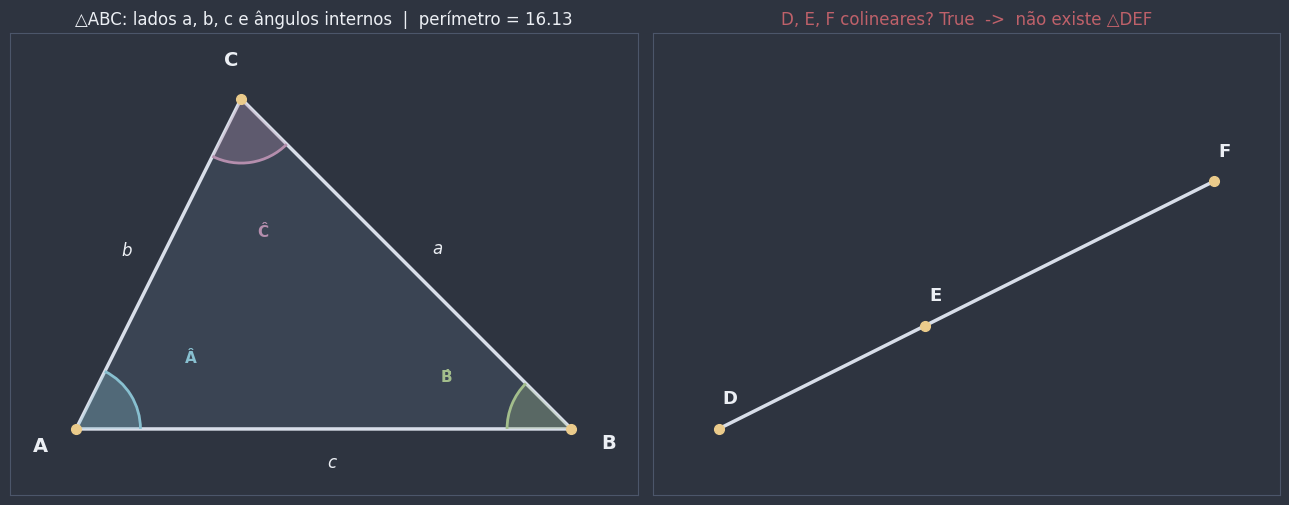

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(NORD_FUNDO)

preparar_eixo(ax1, [A, B, C])
desenhar_triangulo(ax1, A, B, C, rotulos_angulos=["Â", "B̂", "Ĉ"])
ax1.set_title(f"△ABC: lados a, b, c e ângulos internos  |  perímetro = {perimetro:.2f}", color=NORD_TEXTO, fontsize=12)

D, E, F = (0, 0), (2.5, 1.25), (6, 3)
preparar_eixo(ax2, [A, B, C])
ax2.plot(*zip(D, F), color=NORD_TEXTO_SEC, lw=2.5)
for ponto, nome in zip((D, E, F), ("D", "E", "F")):
    desenhar_ponto(ax2, ponto, nome, deslocamento=(0.05, 0.3))
colineares = tres_pontos_colineares(D, E, F)
ax2.set_title(f"D, E, F colineares? {colineares}  ->  não existe △DEF", color=COR_ALERTA, fontsize=12)

plt.tight_layout()
plt.show()

**Ângulos externos.** Em cada vértice, prolongue um dos lados para além do vértice (a linha tracejada no desenho abaixo). O ângulo entre esse prolongamento e o outro lado é um **ângulo externo**. Como o lado e o seu prolongamento formam um ângulo **raso** (180°), o ângulo interno e o externo de um mesmo vértice são **adjacentes e suplementares**, exatamente como você viu em [`0403a_angulos.ipynb`](0403a_angulos.ipynb):

$$\text{ângulo interno} + \text{ângulo externo} = 180^\circ \quad \text{(no mesmo vértice)}$$

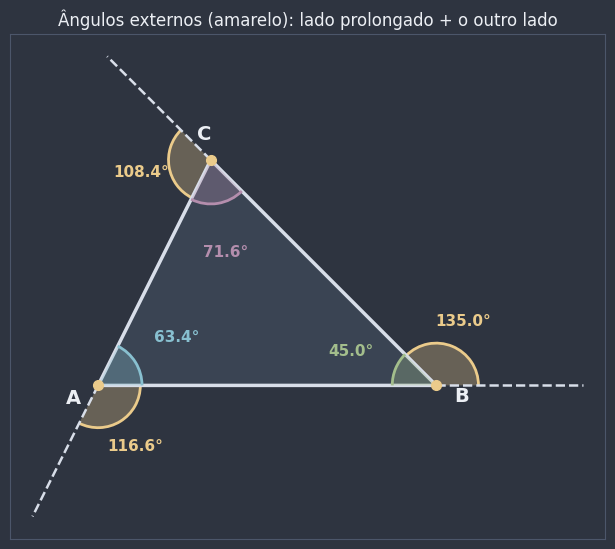

vértice,interno,externo,interno + externo
A,63.4°,116.6°,180.0°
B,45.0°,135.0°,180.0°
C,71.6°,108.4°,180.0°


In [4]:
def ponto_do_prolongamento(anterior, vertice, comprimento: float) -> np.ndarray:
    """Ponto na reta que vai de `anterior` até `vertice`, `comprimento` unidades ALÉM do vértice."""
    anterior, vertice = np.array(anterior, dtype=float), np.array(vertice, dtype=float)
    sentido = (vertice - anterior) / np.linalg.norm(vertice - anterior)
    return vertice + comprimento * sentido


pontos = [np.array(P, dtype=float) for P in (A, B, C)]
nomes = ["A", "B", "C"]
fig, ax = plt.subplots(figsize=(8, 5.6))
fig.patch.set_facecolor(NORD_FUNDO)
extremos = []
linhas = []
for k in range(3):
    # Prolongamos o lado que CHEGA em cada vértice: CA além de A, AB além de B, BC além de C
    anterior, vertice, seguinte = pontos[k - 1], pontos[k], pontos[(k + 1) % 3]
    E = ponto_do_prolongamento(anterior, vertice, 2.6)
    extremos.append(E)
    ax.plot(*zip(vertice, E), color=NORD_TEXTO_SEC, lw=1.8, linestyle="--")
    externo = medir_angulo(vertice, E, seguinte)
    interno = medir_angulo(vertice, anterior, seguinte)
    desenhar_arco(ax, vertice, E, seguinte, raio=0.75, cor=COR_AVISO, rotulo=f"{externo:.1f}°", raio_rotulo=1.25)
    linhas.append({"vértice": nomes[k], "interno": interno, "externo": externo, "interno + externo": interno + externo})

preparar_eixo(ax, pontos + extremos, margem=0.4)
desenhar_triangulo(ax, *pontos, lados=False, rotulos_angulos=[f"{l['interno']:.1f}°" for l in linhas])
ax.set_title("Ângulos externos (amarelo): lado prolongado + o outro lado", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

display(pd.DataFrame(linhas).style.format({"interno": "{:.1f}°", "externo": "{:.1f}°", "interno + externo": "{:.1f}°"}).hide(axis="index"))

💡 **Dica:** em cada vértice há, na verdade, **dois** ângulos externos, um para cada lado que você escolher prolongar. Eles são opostos pelo vértice, portanto **congruentes**. Por isso, falar em "o ângulo externo do vértice C" não gera confusão: os dois têm a mesma medida.

🎯 **Aplicação prática — treliças e portões:** a rigidez do gancho é a razão de existir das **treliças**, estruturas feitas só de barras ligadas em triângulos. Uma ponte de treliça é uma fileira de triângulos; um portão de madeira vira dois triângulos quando ganha a tábua diagonal. Cada triângulo, com seus três lados fixos, não se deforma, e a estrutura inteira fica firme.

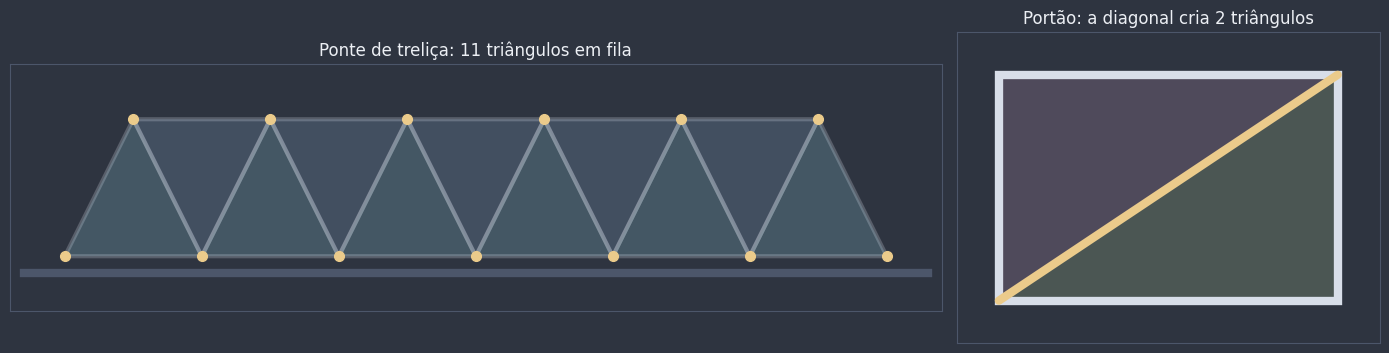

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [2.2, 1]})
fig.patch.set_facecolor(NORD_FUNDO)

# Esquerda: treliça do tipo Warren (uma fileira de triângulos)
vaos = 6
baixo = [np.array([x, 0.0]) for x in range(vaos + 1)]
cima = [np.array([x + 0.5, 1.0]) for x in range(vaos)]
triangulos_trelica = []
for i in range(vaos):
    triangulos_trelica.append([baixo[i], baixo[i + 1], cima[i]])
    if i < vaos - 1:
        triangulos_trelica.append([cima[i], cima[i + 1], baixo[i + 1]])
preparar_eixo(ax1, baixo + cima, margem=0.4)
for k, tri in enumerate(triangulos_trelica):
    ax1.add_patch(Polygon(tri, closed=True, facecolor=COR_PONTO if k % 2 == 0 else COR_SECUNDARIA, alpha=0.25,
                          edgecolor=NORD_TEXTO_SEC, lw=3))
for p in baixo + cima:
    ax1.plot(*p, "o", color=COR_AVISO, markersize=7, zorder=5)
ax1.plot([-0.3, vaos + 0.3], [-0.12, -0.12], color=NORD_LINHA, lw=6)
ax1.set_title(f"Ponte de treliça: {len(triangulos_trelica)} triângulos em fila", color=NORD_TEXTO, fontsize=12)

# Direita: portão com a tábua diagonal
cantos = [np.array(p, dtype=float) for p in [(0, 0), (2.4, 0), (2.4, 1.6), (0, 1.6)]]
preparar_eixo(ax2, cantos, margem=0.3)
ax2.add_patch(Polygon([cantos[0], cantos[1], cantos[2]], closed=True, facecolor=COR_DESTAQUE, alpha=0.25))
ax2.add_patch(Polygon([cantos[0], cantos[2], cantos[3]], closed=True, facecolor=COR_EXTRA, alpha=0.25))
ax2.add_patch(Polygon(cantos, closed=True, fill=False, edgecolor=NORD_TEXTO_SEC, lw=6))
ax2.plot(*zip(cantos[0], cantos[2]), color=COR_AVISO, lw=6, solid_capstyle="round")
ax2.set_title("Portão: a diagonal cria 2 triângulos", color=NORD_TEXTO, fontsize=12)

plt.tight_layout()
plt.show()

⚠️ **Erro comum:** confundir o **lado** $a$ com o **vértice** A. O lado $a$ **não** encosta no vértice A: ele é o segmento $\overline{BC}$, o lado que fica **de frente** para A. Uma forma de lembrar: "a letra minúscula mora do outro lado da maiúscula".

📖 **Leitura complementar:** [Triângulo](https://pt.wikipedia.org/wiki/Tri%C3%A2ngulo) · [Treliça](https://pt.wikipedia.org/wiki/Treli%C3%A7a)

**Pergunta de checagem:** por que três pontos **colineares** não formam um triângulo? O que aconteceria com os três "lados"?

**Pergunta de checagem:** no $\triangle PQR$, qual é o lado $q$? E qual ângulo fica oposto ao lado $\overline{PQ}$?

## 2. Classificação dos triângulos

Existem duas "réguas" para classificar um triângulo: olhando para os **lados** ou olhando para os **ângulos**. Cada triângulo recebe **um nome de cada tipo**.

**Quanto aos lados:**

| Nome | Condição | Detalhe |
|---|---|---|
| **equilátero** | os **três** lados são congruentes | $a = b = c$ |
| **isósceles** | **pelo menos dois** lados são congruentes | o lado diferente é a **base**; os ângulos que tocam a base são os **ângulos da base**; o ângulo oposto à base é o **ângulo do vértice** |
| **escaleno** | os três lados têm medidas **diferentes** | $a \neq b$, $b \neq c$, $a \neq c$ |

Repare na expressão **"pelo menos dois"**: com essa convenção, **todo triângulo equilátero também é isósceles** (ele tem três lados iguais, então certamente tem dois). O equilátero é um caso **particular** de isósceles. Quando uma função precisar dar um só nome, ela vai dar o mais específico: "equilátero".

**Quanto aos ângulos:**

| Nome | Condição | Detalhe |
|---|---|---|
| **acutângulo** | os **três** ângulos são agudos (< 90°) | |
| **retângulo** | **um** ângulo é reto (= 90°) | os lados que formam o ângulo reto são os **catetos**; o lado oposto ao ângulo reto é a **hipotenusa** |
| **obtusângulo** | **um** ângulo é obtuso (> 90°) | |

📌 **Propriedade do triângulo isósceles:** os **ângulos da base são congruentes**. Consequência: no triângulo **equilátero**, qualquer lado pode fazer papel de base, então os **três** ângulos são congruentes (e na seção 3 você vai descobrir quanto cada um mede).

📎 **Conexão:** por enquanto, aceite essa propriedade observando os desenhos e os números. A **demonstração** usa congruência de triângulos e será feita em [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb), o próximo notebook.

Para classificar pelos ângulos, basta olhar para o **maior** ângulo: se ele é agudo, os outros também são; se é reto ou obtuso, ele decide a classificação. (A seção 3 explica por que nunca aparecem dois ângulos retos ou obtusos no mesmo triângulo.)

Como o computador trabalha com números decimais aproximados, comparamos medidas com `math.isclose` e uma **tolerância** relativa (`rel_tol`), em vez de `==`.

In [6]:
def classificar_por_lados(a: float, b: float, c: float, tolerancia: float = 1e-9) -> str:
    """Classifica um triângulo pelas medidas dos lados: 'equilátero', 'isósceles' ou 'escaleno'."""
    def iguais(x: float, y: float) -> bool:
        return math.isclose(x, y, rel_tol=tolerancia)

    if iguais(a, b) and iguais(b, c):
        return "equilátero"
    if iguais(a, b) or iguais(b, c) or iguais(a, c):
        return "isósceles"
    return "escaleno"


def classificar_por_angulos(alfa: float, beta: float, gama: float, tolerancia: float = 1e-9) -> str:
    """Classifica um triângulo pelos ângulos internos: 'acutângulo', 'retângulo' ou 'obtusângulo'."""
    maior = max(alfa, beta, gama)
    if math.isclose(maior, 90, rel_tol=tolerancia):
        return "retângulo"
    return "obtusângulo" if maior > 90 else "acutângulo"


def classificar_triangulo(A, B, C, tolerancia: float = 1e-9) -> tuple[str, str]:
    """Recebe os vértices por coordenadas e devolve (classificação pelos lados, classificação pelos ângulos)."""
    a, b, c = distancia(B, C), distancia(C, A), distancia(A, B)
    angulos = medir_angulo(A, B, C), medir_angulo(B, C, A), medir_angulo(C, A, B)
    return classificar_por_lados(a, b, c, tolerancia), classificar_por_angulos(*angulos, tolerancia=tolerancia)


exemplos_classificacao = {
    "T1": ((0, 0), (4, 0), (2, 2 * math.sqrt(3))),
    "T2": ((0, 0), (4, 0), (2, 2)),
    "T3": ((0, 0), (4, 0), (0, 3)),
    "T4": ((0, 0), (4, 0), (2, 0.9)),
    "T5": ((0, 0), (4, 0), (1.5, 3)),
    "T6": ((0, 0), (4, 0), (-1, 2)),
}
linhas = []
for nome, (P, Q, R) in exemplos_classificacao.items():
    por_lados, por_angulos = classificar_triangulo(P, Q, R)
    linhas.append({
        "triângulo": nome,
        "lados a, b, c": ", ".join(f"{m:.2f}" for m in (distancia(Q, R), distancia(R, P), distancia(P, Q))),
        "ângulos Â, B̂, Ĉ": ", ".join(f"{m:.1f}°" for m in (medir_angulo(P, Q, R), medir_angulo(Q, R, P), medir_angulo(R, P, Q))),
        "quanto aos lados": por_lados,
        "quanto aos ângulos": por_angulos,
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

triângulo,"lados a, b, c","ângulos Â, B̂, Ĉ",quanto aos lados,quanto aos ângulos
T1,"4.00, 4.00, 4.00","60.0°, 60.0°, 60.0°",equilátero,acutângulo
T2,"2.83, 2.83, 4.00","45.0°, 45.0°, 90.0°",isósceles,retângulo
T3,"5.00, 3.00, 4.00","90.0°, 36.9°, 53.1°",escaleno,retângulo
T4,"2.19, 2.19, 4.00","24.2°, 24.2°, 131.5°",isósceles,obtusângulo
T5,"3.91, 3.35, 4.00","63.4°, 50.2°, 66.4°",escaleno,acutângulo
T6,"5.39, 2.24, 4.00","116.6°, 21.8°, 41.6°",escaleno,obtusângulo


Juntando as duas classificações, dá para montar uma "tabela de combinações" com 3 × 3 = 9 casas. Será que todas existem? Na figura, cada linha é uma classificação pelos lados e cada coluna, uma classificação pelos ângulos. Os **tracinhos** marcam os lados congruentes, como em [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb).

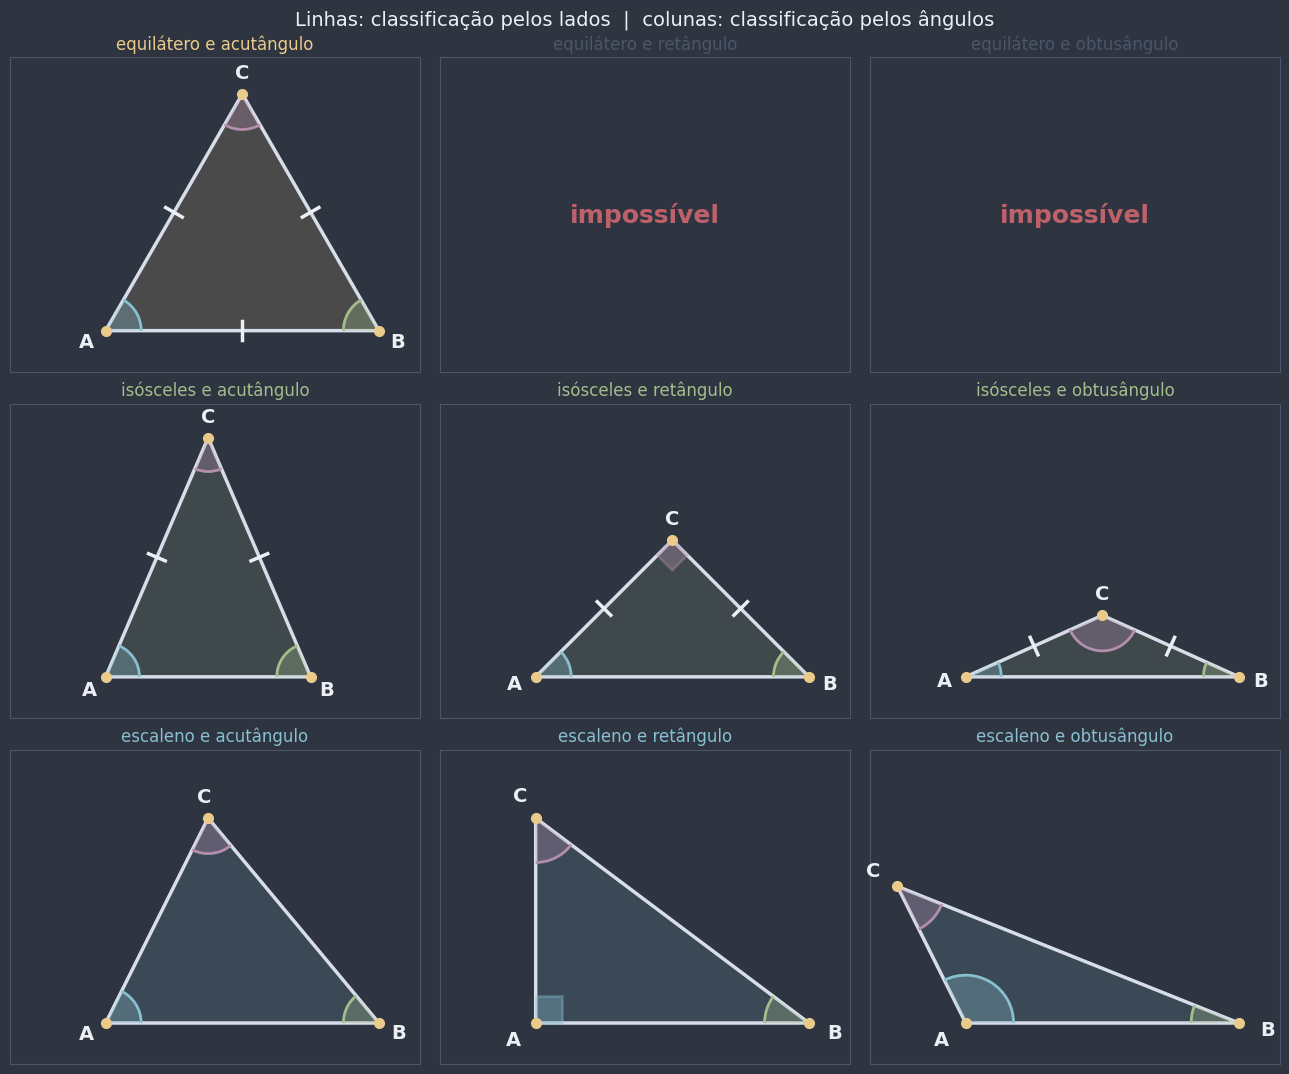

In [7]:
CORES_LADOS = {"equilátero": COR_AVISO, "isósceles": COR_DESTAQUE, "escaleno": COR_PONTO}
classes_lados = ["equilátero", "isósceles", "escaleno"]
classes_angulos = ["acutângulo", "retângulo", "obtusângulo"]
grade = {
    ("equilátero", "acutângulo"): exemplos_classificacao["T1"],
    ("isósceles", "acutângulo"): ((0, 0), (3, 0), (1.5, 3.5)),
    ("isósceles", "retângulo"): exemplos_classificacao["T2"],
    ("isósceles", "obtusângulo"): exemplos_classificacao["T4"],
    ("escaleno", "acutângulo"): exemplos_classificacao["T5"],
    ("escaleno", "retângulo"): exemplos_classificacao["T3"],
    ("escaleno", "obtusângulo"): exemplos_classificacao["T6"],
}

fig, eixos = plt.subplots(3, 3, figsize=(13, 11))
fig.patch.set_facecolor(NORD_FUNDO)
for i, classe_l in enumerate(classes_lados):
    for j, classe_a in enumerate(classes_angulos):
        ax = eixos[i, j]
        if (classe_l, classe_a) in grade:
            P, Q, R = grade[(classe_l, classe_a)]
            preparar_eixo(ax, [(-1.2, -0.4), (4.4, 3.8)], margem=0.2)
            desenhar_triangulo(ax, P, Q, R, lados=False, tracinhos=True, cor_preenchimento=CORES_LADOS[classe_l])
            obtido = classificar_triangulo(P, Q, R)
            ax.set_title(f"{obtido[0]} e {obtido[1]}", color=CORES_LADOS[classe_l], fontsize=12)
        else:
            preparar_eixo(ax, [(-1.2, -0.4), (4.4, 3.8)], margem=0.2)
            ax.text(1.6, 1.7, "impossível", color=COR_ALERTA, fontsize=18, ha="center", va="center", fontweight="bold")
            ax.set_title(f"{classe_l} e {classe_a}", color=NORD_LINHA, fontsize=12)
fig.suptitle("Linhas: classificação pelos lados  |  colunas: classificação pelos ângulos", color=NORD_TEXTO, fontsize=14)
plt.tight_layout()
plt.show()

Sete das nove combinações existem. As duas casas "impossíveis" são do equilátero: como os três ângulos dele são congruentes, se um fosse reto (ou obtuso), os três seriam, e isso não cabe num triângulo (a seção 3 mostra por quê).

🕹️ **Widget interativo:** os vértices A = (0, 0) e B = (4, 0) estão fixos; os sliders movem o vértice C. O título mostra as duas classificações, com a cor mudando conforme a classificação pelos lados. Tente encontrar:
- um triângulo **isósceles** (dica: coloque C bem em cima do meio de $\overline{AB}$, com `x de C` = 2);
- um triângulo **retângulo** com o ângulo reto em A, e outro com o ângulo reto em C (dica: experimente C = (2; 2) ou C = (0,8; 1,6));
- um triângulo **equilátero** (dica: `x de C` = 2 e `y de C` perto de 3,45).

Como o slider anda de 0,05 em 0,05, é impossível acertar a altura exata do equilátero ($2\sqrt{3} \approx 3{,}4641$). Por isso o widget usa uma tolerância maior, de **1%**: medidas que diferem menos de 1% contam como iguais.

In [ ]:
def explorar_classificacao(x_c: float, y_c: float) -> None:
    A, B, C = (0.0, 0.0), (4.0, 0.0), (x_c, y_c)
    fig, ax = plt.subplots(figsize=(7.5, 5.8))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-2.2, -0.5), (6.2, 4.6)], margem=0.2)
    if tres_pontos_colineares(A, B, C):
        ax.plot([-2, 6], [0, 0], color=NORD_TEXTO_SEC, lw=2.5)
        ax.set_title("A, B e C colineares: não há triângulo", color=COR_ALERTA, fontsize=13)
    else:
        por_lados, por_angulos = classificar_triangulo(A, B, C, tolerancia=0.01)
        a, b, c = distancia(B, C), distancia(C, A), distancia(A, B)
        angulos = medir_angulo(A, B, C), medir_angulo(B, C, A), medir_angulo(C, A, B)
        desenhar_triangulo(ax, A, B, C, rotulos_lados=[f"a = {a:.2f}", f"b = {b:.2f}", f"c = {c:.2f}"],
                           rotulos_angulos=[f"{m:.1f}°" for m in angulos], cor_preenchimento=CORES_LADOS[por_lados],
                           tracinhos=True, tolerancia=0.01)
        ax.set_title(f"{por_lados} e {por_angulos}", color=CORES_LADOS[por_lados], fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_classificacao,
    x_c=widgets.FloatSlider(value=1.2, min=-2, max=6, step=0.05, description="x de C:"),
    y_c=widgets.FloatSlider(value=2.5, min=0, max=4.5, step=0.05, description="y de C:"),
);

interactive(children=(FloatSlider(value=1.2, description='x de C:', max=6.0, min=-2.0, step=0.05), FloatSlider…

⚠️ **Erro comum:** achar que "equilátero" e "isósceles" são categorias que se excluem. Não se excluem: pela definição ("pelo menos dois lados congruentes"), **todo equilátero é isósceles**, mas nem todo isósceles é equilátero. Outro erro é imaginar um triângulo com **dois** ângulos retos, ou com dois obtusos. Tente desenhar um: as semirretas não se encontram. A seção 3 explica o porquê.

📎 **Conexão:** a classificação quanto aos ângulos também pode ser feita **só com os lados**, comparando o quadrado do maior lado com a soma dos quadrados dos outros dois (uma extensão do Teorema de Pitágoras). Isso será visto em 📌 Triângulos Retângulos.

**Pergunta de checagem:** um triângulo pode ser ao mesmo tempo **isósceles e retângulo**? E **equilátero e obtusângulo**? Use a grade 3 × 3 acima para conferir.

**Pergunta de checagem:** num triângulo retângulo, a hipotenusa é oposta a qual ângulo? Você acha que ela é o maior lado? (A seção 4 responde.)

## 3. Soma dos ângulos internos e ângulo externo

Aqui está, provavelmente, o fato mais famoso sobre triângulos:

📌 **Soma dos ângulos internos:** em **qualquer** triângulo,

$$\hat{A} + \hat{B} + \hat{C} = 180^\circ$$

Nesta etapa vamos **verificar** esse resultado de forma experimental (medindo muitos triângulos) e **intuitiva** (recortando os cantos de um triângulo). A **demonstração** formal precisa de retas paralelas.

📎 **Conexão:** a demonstração do 180° virá em [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb), traçando por um vértice uma reta paralela ao lado oposto.

**Primeiro, a representação numérica:** vamos sortear triângulos com vértices em posições aleatórias, medir os três ângulos com o transferidor digital e somar.

In [9]:
rng = np.random.default_rng(404)
linhas = []
while len(linhas) < 8:
    P, Q, R = (rng.uniform(-5, 5, size=2) for _ in range(3))
    # Descartamos trios quase colineares, que dariam triângulos "achatados" demais
    area_dobrada = abs((Q[0] - P[0]) * (R[1] - P[1]) - (Q[1] - P[1]) * (R[0] - P[0]))
    if area_dobrada < 2:
        continue
    angulos = medir_angulo(P, Q, R), medir_angulo(Q, R, P), medir_angulo(R, P, Q)
    linhas.append({
        "triângulo": f"sorteio {len(linhas) + 1}",
        "Â": angulos[0], "B̂": angulos[1], "Ĉ": angulos[2],
        "Â + B̂ + Ĉ": sum(angulos),
    })
display(pd.DataFrame(linhas).style.format({"Â": "{:.2f}°", "B̂": "{:.2f}°", "Ĉ": "{:.2f}°", "Â + B̂ + Ĉ": "{:.6f}°"}).hide(axis="index"))

triângulo,Â,B̂,Ĉ,Â + B̂ + Ĉ
sorteio 1,146.91°,18.62°,14.47°,180.000000°
sorteio 2,32.68°,42.22°,105.10°,180.000000°
sorteio 3,105.78°,1.67°,72.56°,180.000000°
sorteio 4,118.45°,40.50°,21.05°,180.000000°
sorteio 5,85.69°,58.69°,35.62°,180.000000°
sorteio 6,31.36°,69.86°,78.78°,180.000000°
sorteio 7,57.54°,67.80°,54.66°,180.000000°
sorteio 8,69.11°,64.54°,46.34°,180.000000°


Triângulos completamente diferentes, e a soma dá **180°** em todos (as casas decimais finais são só o arredondamento do computador).

**Agora a representação gráfica:** imagine o triângulo recortado em papel. Rasgue os três cantos e junte-os lado a lado, com as pontas no mesmo ponto. Os três ângulos se encaixam formando um **ângulo raso**, uma meia-volta, uma linha reta.

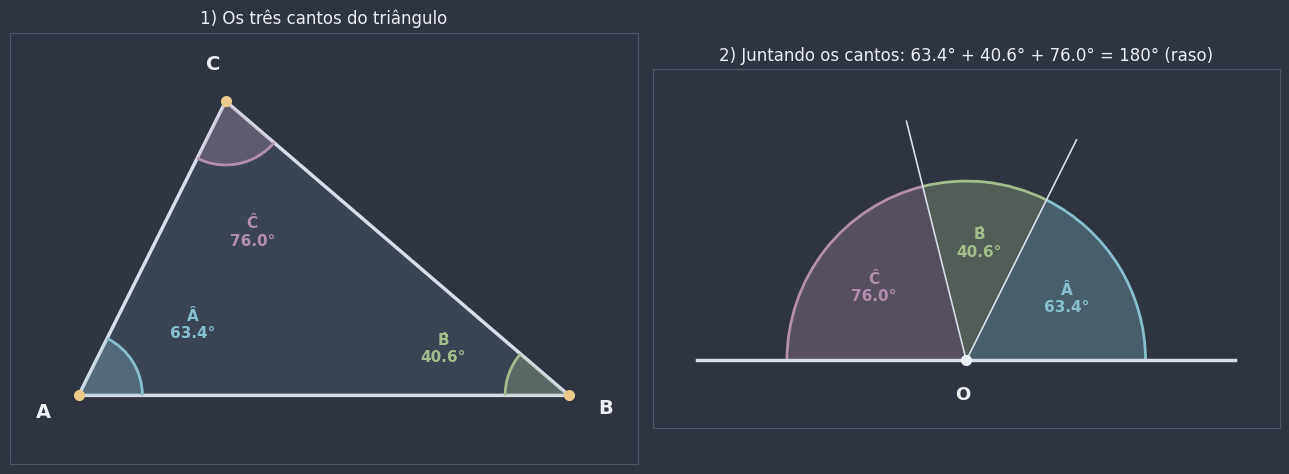

In [10]:
A, B, C = (0, 0), (5, 0), (1.5, 3)
angulos = medir_angulo(A, B, C), medir_angulo(B, C, A), medir_angulo(C, A, B)
simbolos = ["Â", "B̂", "Ĉ"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)

preparar_eixo(ax1, [A, B, C], margem=0.7)
desenhar_triangulo(ax1, A, B, C, lados=False,
                   rotulos_angulos=[f"{s}\n{m:.1f}°" for s, m in zip(simbolos, angulos)])
ax1.set_title("1) Os três cantos do triângulo", color=NORD_TEXTO, fontsize=12)

# Os três "cantos recortados", colocados lado a lado com a ponta no mesmo ponto O
O = (0, 0)
preparar_eixo(ax2, [(-2.6, -0.4), (2.6, 2.4)], margem=0.2)
inicio = 0
for simbolo, medida, cor in zip(simbolos, angulos, CORES_VERTICES):
    desenhar_setor(ax2, O, inicio, medida, raio=1.6, cor=cor, rotulo=f"{simbolo}\n{medida:.1f}°",
                   raio_rotulo=1.05, marcar_reto=False)
    ax2.plot(*zip(O, 2.2 * direcao(inicio)), color=NORD_TEXTO_SEC, lw=1.2)
    inicio += medida
ax2.plot([-2.4, 2.4], [0, 0], color=NORD_TEXTO_SEC, lw=2.5)
desenhar_ponto(ax2, O, "O", cor=NORD_TEXTO, deslocamento=(-0.1, -0.35))
ax2.set_title(f"2) Juntando os cantos: {' + '.join(f'{m:.1f}°' for m in angulos)} = {sum(angulos):.0f}° (raso)",
              color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

**Consequências imediatas da soma 180°:**

1. **Um triângulo tem no máximo um ângulo reto ou obtuso.** Se tivesse dois ângulos de pelo menos 90°, só eles já somariam 180° ou mais, e não sobraria nada para o terceiro ângulo.
2. **Cada ângulo do triângulo equilátero mede 60°.** Os três são congruentes (seção 2) e somam 180°: $3x = 180^\circ \Rightarrow x = 60^\circ$. Era por isso que o triângulo de varetas 2, 2, 2 do gancho só fechava com 60°!
3. **Num triângulo retângulo, os dois ângulos agudos são complementares.** Tirando o ângulo reto, sobram $180^\circ - 90^\circ = 90^\circ$ para os outros dois.
4. **Teorema do ângulo externo.** Num vértice, interno + externo = 180°; no triângulo todo, os três internos também somam 180°. Comparando as duas contas no vértice C:

$$\hat{C} + \text{ext}(C) = 180^\circ = \hat{A} + \hat{B} + \hat{C} \quad \Longrightarrow \quad \text{ext}(C) = \hat{A} + \hat{B}$$

📌 **Teorema do ângulo externo:** cada ângulo externo de um triângulo é igual à **soma dos dois ângulos internos não adjacentes** a ele. Consequência: o ângulo externo é **maior** que cada um desses dois internos.

No desenho abaixo, o ângulo externo em C (entre o prolongamento de $\overline{AC}$ e o lado $\overline{CB}$) aparece preenchido por uma cópia de $\hat{A}$ e uma cópia de $\hat{B}$, encaixadas certinho. A linha pontilhada, paralela a $\overline{AB}$, é a ideia-chave da demonstração que virá em [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb).

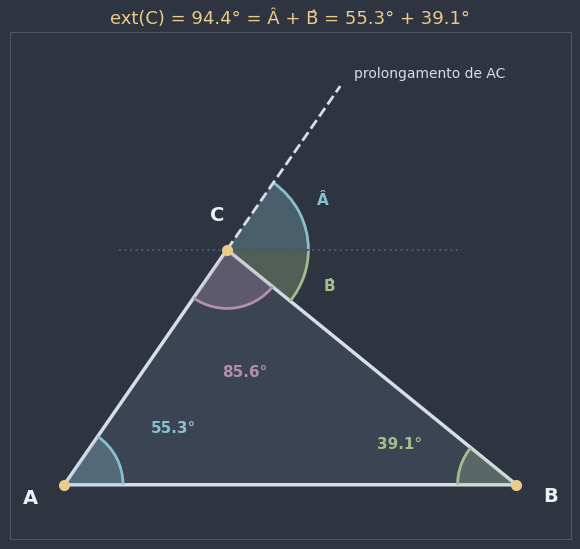

In [11]:
A, B, C = np.array([0.0, 0.0]), np.array([5.0, 0.0]), np.array([1.8, 2.6])
angulo_a, angulo_b, angulo_c = medir_angulo(A, B, C), medir_angulo(B, C, A), medir_angulo(C, A, B)
D = ponto_do_prolongamento(A, C, 2.2)  # prolongamento de AC além de C

fig, ax = plt.subplots(figsize=(8.5, 5.6))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [A, B, C, D], margem=0.6)
desenhar_triangulo(ax, A, B, C, lados=False,
                   rotulos_angulos=[f"{angulo_a:.1f}°", f"{angulo_b:.1f}°", f"{angulo_c:.1f}°"])
ax.plot(*zip(C, D), color=NORD_TEXTO_SEC, lw=2, linestyle="--")
ax.plot([C[0] - 1.2, C[0] + 2.6], [C[1], C[1]], color=NORD_LINHA, lw=1.5, linestyle=":")

# Dentro do externo: cópia de Â (entre a paralela e o prolongamento) e cópia de B̂ (entre CB e a paralela)
desenhar_setor(ax, C, 0, direcao_de(C, D), raio=0.9, cor=CORES_VERTICES[0], rotulo="Â", raio_rotulo=1.2,
               marcar_reto=False)
desenhar_setor(ax, C, direcao_de(C, B), -direcao_de(C, B), raio=0.9, cor=CORES_VERTICES[1], rotulo="B̂",
               raio_rotulo=1.2, marcar_reto=False)
externo_c = medir_angulo(C, D, B)
ax.text(*(D + np.array([0.15, 0.1])), "prolongamento de AC", color=NORD_TEXTO_SEC, fontsize=10)
ax.set_title(f"ext(C) = {externo_c:.1f}° = Â + B̂ = {angulo_a:.1f}° + {angulo_b:.1f}°", color=COR_AVISO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** escolha $\hat{A}$ e $\hat{B}$ com os sliders; o terceiro ângulo é calculado sozinho ($\hat{C} = 180^\circ - \hat{A} - \hat{B}$) e o triângulo é redesenhado com a base $\overline{AB}$ fixa. Em amarelo aparecem os **três ângulos externos**, e o título confere o teorema em cada vértice. Depois, tente fazer $\hat{A} + \hat{B}$ chegar a 180° ou passar disso: o que acontece com os lados que saem de A e de B?

In [ ]:
def construir_por_angulos(alfa: float, beta: float, base: float = 5.0):
    """Vértices (A, B, C) de um triângulo com AB = base, Â = alfa e B̂ = beta.

    Devolve None se as semirretas que saem de A e de B não se encontram (alfa + beta >= 180°).
    """
    if alfa <= 0 or beta <= 0 or alfa + beta >= 180:
        return None
    A, B = np.array([0.0, 0.0]), np.array([float(base), 0.0])
    # C está ao mesmo tempo na semirreta de A (direção alfa) e na semirreta de B (direção 180° - beta)
    t, _ = np.linalg.solve(np.column_stack([direcao(alfa), -direcao(180 - beta)]), B - A)
    return A, B, A + t * direcao(alfa)


def explorar_soma(alfa: int, beta: int) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor(NORD_FUNDO)
    vertices = construir_por_angulos(alfa, beta)
    if vertices is None:
        A, B = np.array([0.0, 0.0]), np.array([5.0, 0.0])
        fim_a, fim_b = A + 6 * direcao(alfa), B + 6 * direcao(180 - beta)
        preparar_eixo(ax, [A, B, fim_a, fim_b], margem=0.8)
        ax.plot(*zip(A, B), color=NORD_TEXTO_SEC, lw=2.5)
        for inicio, fim, cor in [(A, fim_a, CORES_VERTICES[0]), (B, fim_b, CORES_VERTICES[1])]:
            ax.annotate("", xy=fim, xytext=inicio, arrowprops=dict(arrowstyle="-|>", color=cor, lw=2.5, mutation_scale=16))
        desenhar_setor(ax, A, 0, alfa, raio=0.7, cor=CORES_VERTICES[0], rotulo=f"{alfa}°", marcar_reto=False)
        desenhar_setor(ax, B, 180 - beta, beta, raio=0.7, cor=CORES_VERTICES[1], rotulo=f"{beta}°", marcar_reto=False)
        desenhar_ponto(ax, A, "A", deslocamento=(-0.3, -0.45))
        desenhar_ponto(ax, B, "B", deslocamento=(0.1, -0.45))
        ax.set_title(f"Â + B̂ = {alfa + beta}° ≥ 180°: os lados não se encontram\nnão existe triângulo",
                     color=COR_ALERTA, fontsize=13)
    else:
        gama = 180 - alfa - beta
        pontos = list(vertices)
        internos = [alfa, beta, gama]
        extremos = []
        for k in range(3):
            anterior, vertice, seguinte = pontos[k - 1], pontos[k], pontos[(k + 1) % 3]
            tamanho = max(distancia(p, q) for p in pontos for q in pontos)
            E = ponto_do_prolongamento(anterior, vertice, 0.35 * tamanho)
            extremos.append(E)
            ax.plot(*zip(vertice, E), color=NORD_TEXTO_SEC, lw=1.5, linestyle="--")
            desenhar_arco(ax, vertice, E, seguinte, raio=0.09 * tamanho, cor=COR_AVISO,
                          rotulo=f"{180 - internos[k]}°", raio_rotulo=0.19 * tamanho, marcar_reto=False)
        preparar_eixo(ax, pontos + extremos, margem=0.5)
        desenhar_triangulo(ax, *pontos, lados=False, rotulos_angulos=[f"{m}°" for m in internos])
        ax.set_title(
            f"Ĉ = 180° − {alfa}° − {beta}° = {gama}°\n"
            f"ext(A) = {180 - alfa}° = B̂ + Ĉ ✓   ext(B) = {180 - beta}° = Â + Ĉ ✓   ext(C) = {180 - gama}° = Â + B̂ ✓",
            color=NORD_TEXTO, fontsize=11,
        )
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_soma,
    alfa=widgets.IntSlider(value=50, min=10, max=160, step=5, description="Â (°):"),
    beta=widgets.IntSlider(value=70, min=10, max=160, step=5, description="B̂ (°):"),
);

interactive(children=(IntSlider(value=50, description='Â (°):', max=160, min=10, step=5), IntSlider(value=70, …

🎯 **Aplicação prática — medir sem atravessar o rio:** como descobrir a distância até uma árvore do outro lado de um rio, sem molhar os pés? Esse é o princípio da **triangulação**, usada há séculos na topografia e na navegação. Crave duas estacas A e B na sua margem, a uma distância conhecida (a **base**). De cada estaca, meça o ângulo entre a base e a direção da árvore. Pronto: um lado e dois ângulos **travam** o triângulo, e dele sai tudo o que falta. O terceiro ângulo vem de graça da soma 180°, e a posição da árvore sai do cruzamento das duas direções.

Ângulo na árvore, pela soma 180°: 180° − 62° − 71° = 47°
Conferindo com o transferidor digital: 47.0°
Distância da estaca A até a árvore: 77.6 m
Distância da estaca B até a árvore: 72.4 m
Largura do rio (da árvore até a linha das estacas): 68.5 m


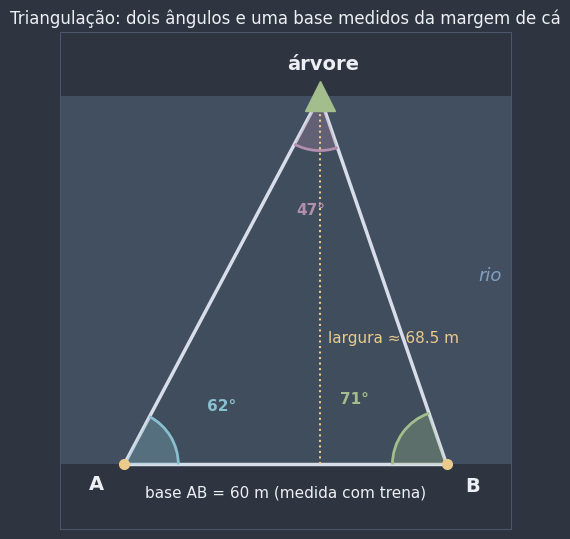

In [13]:
base_rio = 60  # metros entre as estacas A e B, na margem de cá
alfa_medido, beta_medido = 62, 71  # ângulos medidos com um teodolito (um "transferidor de luneta")

A, B, arvore = construir_por_angulos(alfa_medido, beta_medido, base=base_rio)
angulo_na_arvore = 180 - alfa_medido - beta_medido
print(f"Ângulo na árvore, pela soma 180°: 180° − {alfa_medido}° − {beta_medido}° = {angulo_na_arvore}°")
print(f"Conferindo com o transferidor digital: {medir_angulo(arvore, A, B):.1f}°")
print(f"Distância da estaca A até a árvore: {distancia(A, arvore):.1f} m")
print(f"Distância da estaca B até a árvore: {distancia(B, arvore):.1f} m")
print(f"Largura do rio (da árvore até a linha das estacas): {arvore[1]:.1f} m")

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [A, B, arvore], margem=12)
ax.add_patch(plt.Rectangle((-15, 0), base_rio + 30, arvore[1], facecolor=COR_SECUNDARIA, alpha=0.25))
ax.text(base_rio + 8, arvore[1] / 2, "rio", color=COR_SECUNDARIA, fontsize=13, ha="center", style="italic")
desenhar_triangulo(ax, A, B, arvore, nomes=("A", "B", "árvore"), lados=False,
                   rotulos_angulos=[f"{alfa_medido}°", f"{beta_medido}°", f"{angulo_na_arvore}°"], cor_preenchimento=NORD_PAINEL)
ax.plot(*arvore, "^", color=COR_DESTAQUE, markersize=22, zorder=6)
ax.plot([arvore[0], arvore[0]], [0, arvore[1]], color=COR_AVISO, lw=1.5, linestyle=":")
ax.text(arvore[0] + 1.5, arvore[1] / 3, f"largura ≈ {arvore[1]:.1f} m", color=COR_AVISO, fontsize=11)
ax.text(base_rio / 2, -6, f"base AB = {base_rio} m (medida com trena)", color=NORD_TEXTO, fontsize=11, ha="center")
ax.set_title("Triangulação: dois ângulos e uma base medidos da margem de cá", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

🕵️ **Curiosidade histórica — e se o mundo fosse curvo?** A soma de 180° depende de um postulado de Euclides sobre retas paralelas. No século XIX, matemáticos como Gauss, Lobachevsky, Bolyai e Riemann perceberam que, trocando esse postulado, surgem **outras geometrias**, tão coerentes quanto a de Euclides. Na superfície de uma **esfera**, por exemplo, os "lados" de um triângulo são arcos de círculos máximos, e a soma dos ângulos internos é sempre **maior** que 180°. Um triângulo com um vértice no Polo Norte e dois no Equador pode ter **três ângulos retos**: 270° no total! Para distâncias do dia a dia a Terra parece plana e o 180° funciona muito bem; para rotas de avião e navegação por satélite, a geometria da esfera faz diferença.

📖 **Leitura complementar:** [Geometria esférica](https://pt.wikipedia.org/wiki/Geometria_esf%C3%A9rica)

**Pergunta de checagem:** se dois ângulos internos de um triângulo medem 50° e 70°, quanto mede o terceiro? E o ângulo externo adjacente a esse terceiro ângulo?

**Pergunta de checagem:** um triângulo pode ter ângulos internos de 100°, 50° e 40°? E um ângulo externo de 30° pode estar ao lado de um interno de 160°?

## 4. Desigualdades nos triângulos

Volte ao gancho de [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb): o caminho em linha reta entre dois pontos é o mais curto. Num triângulo, ir de B até C pelo lado $a$ é o caminho **reto**; ir de B até C **passando por A** (lados $c$ e $b$) é um desvio, e desvio nunca encurta. Só no caso extremo, quando A está **no** segmento $\overline{BC}$ (os três pontos colineares), o desvio empata com o caminho reto, mas aí não há triângulo.

📌 **Desigualdade triangular:** em qualquer triângulo, **cada lado é menor que a soma dos outros dois** (e maior que a diferença deles):

$$|b - c| < a < b + c$$

e o mesmo vale trocando os papéis: $|a - c| < b < a + c$ e $|a - b| < c < a + b$.

📌 **Condição de existência:** três medidas positivas $a$, $b$ e $c$ formam um triângulo **se, e somente se**, as três desigualdades valem. Na prática, é equivalente a exigir que o **maior lado seja menor que a soma dos outros dois**.

📌 **Relação entre lados e ângulos:** em qualquer triângulo, ao **maior lado** opõe-se o **maior ângulo**, e ao **menor lado**, o **menor ângulo** (e vice-versa). Lados congruentes se opõem a ângulos congruentes, e ângulos congruentes se opõem a lados congruentes.

A última frase é a propriedade do isósceles da seção 2 "em mão dupla": ângulos da base congruentes ⟺ lados congruentes.

In [14]:
def forma_triangulo(a: float, b: float, c: float) -> bool:
    """True se as medidas a, b e c formam um triângulo (desigualdade triangular)."""
    if min(a, b, c) <= 0:
        return False
    return a < b + c and b < a + c and c < a + b


def situacao_das_medidas(a: float, b: float, c: float) -> str:
    """Descreve o que acontece ao tentar montar um triângulo com varetas de tamanho a, b e c."""
    if forma_triangulo(a, b, c):
        return "forma triângulo"
    maior = max(a, b, c)
    if math.isclose(maior, a + b + c - maior):
        return "degenerado (lados deitados numa reta)"
    return "não fecha"


trios = [(3, 4, 5), (5, 5, 5), (2, 3, 4), (3, 4, 7), (3, 4, 8), (1, 2, 10), (10, 2, 1), (6, 6, 11.9)]
linhas = []
for a, b, c in trios:
    maior = max(a, b, c)
    linhas.append({
        "a, b, c": f"{a:g}, {b:g}, {c:g}",
        "maior lado": maior,
        "soma dos outros dois": a + b + c - maior,
        "só testando a < b + c": "✅" if a < b + c else "❌",
        "testando os três": "✅" if forma_triangulo(a, b, c) else "❌",
        "situação": situacao_das_medidas(a, b, c),
    })
display(pd.DataFrame(linhas).style.format({"maior lado": "{:g}", "soma dos outros dois": "{:g}"}).hide(axis="index"))

"a, b, c",maior lado,soma dos outros dois,só testando a < b + c,testando os três,situação
"3, 4, 5",5,7,✅,✅,forma triângulo
"5, 5, 5",5,10,✅,✅,forma triângulo
"2, 3, 4",4,5,✅,✅,forma triângulo
"3, 4, 7",7,7,✅,❌,degenerado (lados deitados numa reta)
"3, 4, 8",8,7,✅,❌,não fecha
"1, 2, 10",10,3,✅,❌,não fecha
"10, 2, 1",10,3,❌,❌,não fecha
"6, 6, 11.9",11.9,12,✅,✅,forma triângulo


Repare no trio (1, 2, 10): a desigualdade $a < b + c$ vale ($1 < 12$), mas as varetas de 1 e 2 nunca vão alcançar as pontas da vareta de 10. Testar só uma das desigualdades engana!

**Por que as varetas não fecham?** Coloque a vareta maior deitada. A vareta $c$ gira presa numa ponta, e a sua outra ponta desenha uma **circunferência** de raio $c$; o mesmo faz a vareta $b$ na outra ponta. O terceiro vértice precisa estar **nas duas circunferências ao mesmo tempo**. Veja os três casos com varetas de 3 e 4:

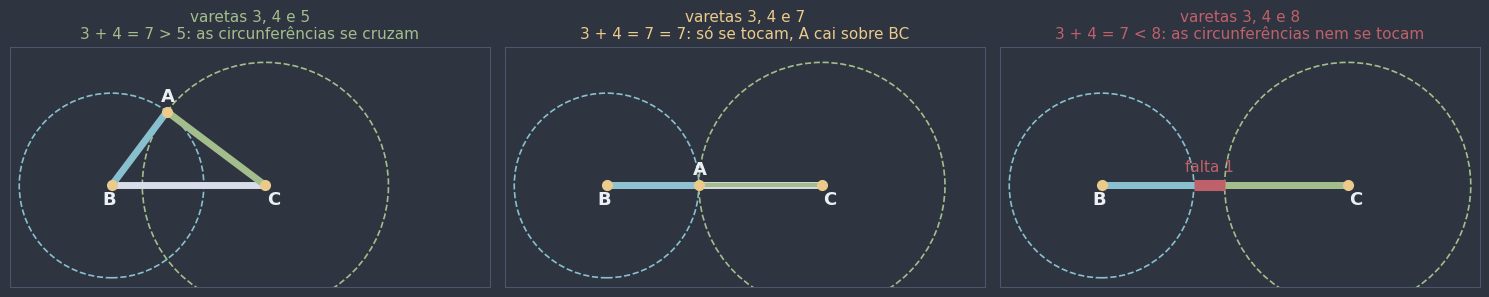

In [15]:
def construir_por_lados(a: float, b: float, c: float):
    """Vértices (A, B, C) de um triângulo com BC = a, CA = b e AB = c, ou None se ele não existir.

    B fica em (0, 0) e C em (a, 0); A é o cruzamento da circunferência de centro B e raio c
    com a circunferência de centro C e raio b (no caso degenerado, A cai na reta BC).
    """
    if min(a, b, c) <= 0:
        return None
    x = (a**2 + c**2 - b**2) / (2 * a)
    altura_ao_quadrado = c**2 - x**2
    if altura_ao_quadrado < -1e-9:
        return None
    return np.array([x, math.sqrt(max(altura_ao_quadrado, 0))]), np.array([0.0, 0.0]), np.array([float(a), 0.0])


fig, eixos = plt.subplots(1, 3, figsize=(15, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, base in zip(eixos, [5, 7, 8]):
    b, c = 4, 3  # a vareta b sai de C e a vareta c sai de B
    B, C = np.array([0.0, 0.0]), np.array([float(base), 0.0])
    preparar_eixo(ax, [(-3.2, -3.2), (12.2, 4.4)], margem=0.1)
    ax.add_patch(Circle(B, c, fill=False, edgecolor=COR_PONTO, lw=1.2, linestyle="--"))
    ax.add_patch(Circle(C, b, fill=False, edgecolor=COR_DESTAQUE, lw=1.2, linestyle="--"))
    ax.plot(*zip(B, C), color=NORD_TEXTO_SEC, lw=5, solid_capstyle="round")
    resultado = construir_por_lados(base, b, c)
    if resultado is not None and resultado[0][1] > 1e-9:
        A = resultado[0]
        ax.plot(*zip(B, A), color=COR_PONTO, lw=5, solid_capstyle="round")
        ax.plot(*zip(C, A), color=COR_DESTAQUE, lw=5, solid_capstyle="round")
        desenhar_ponto(ax, A, "A", deslocamento=(-0.2, 0.35))
        titulo, cor = f"3 + 4 = 7 > {base}: as circunferências se cruzam", COR_DESTAQUE
    elif resultado is not None:
        A = resultado[0]
        ax.plot(*zip(B, A), color=COR_PONTO, lw=5, solid_capstyle="round", alpha=0.9)
        ax.plot(*zip(A, C), color=COR_DESTAQUE, lw=3, solid_capstyle="round")
        desenhar_ponto(ax, A, "A", deslocamento=(-0.2, 0.35))
        titulo, cor = f"3 + 4 = 7 = {base}: só se tocam, A cai sobre BC", COR_AVISO
    else:
        ponta_c, ponta_b = B + c * direcao(0), C + b * direcao(180)
        ax.plot(*zip(B, ponta_c), color=COR_PONTO, lw=5, solid_capstyle="round")
        ax.plot(*zip(C, ponta_b), color=COR_DESTAQUE, lw=5, solid_capstyle="round")
        ax.plot(*zip(ponta_c, ponta_b), color=COR_ALERTA, lw=8, solid_capstyle="butt")
        ax.text(*(ponta_c + ponta_b) / 2 + np.array([0, 0.45]), "falta 1", color=COR_ALERTA, fontsize=11, ha="center")
        titulo, cor = f"3 + 4 = 7 < {base}: as circunferências nem se tocam", COR_ALERTA
    desenhar_ponto(ax, B, "B", deslocamento=(-0.3, -0.6))
    desenhar_ponto(ax, C, "C", deslocamento=(0.05, -0.6))
    ax.set_title(f"varetas 3, 4 e {base}\n{titulo}", color=cor, fontsize=11)
plt.tight_layout()
plt.show()

Agora a relação entre lados e ângulos, na forma de tabela. Para cada trio de lados, o computador monta o triângulo, mede os ângulos e confere se o maior ângulo está oposto ao maior lado.

In [16]:
def nome_do_maior(valores, nomes) -> str:
    """Nome do maior valor da lista (ou 'empate', se o maior valor aparecer mais de uma vez)."""
    maior = max(valores)
    donos = [n for v, n in zip(valores, nomes) if math.isclose(v, maior)]
    return donos[0] if len(donos) == 1 else "empate: " + " e ".join(donos)


oposto_ao_lado = {"a": "Â", "b": "B̂", "c": "Ĉ"}
linhas = []
for lados in [(3, 4, 5), (5, 5, 8), (7, 8, 9), (2, 6, 7), (9, 4, 6), (6, 6, 6)]:
    A, B, C = construir_por_lados(*lados)
    angulos = (medir_angulo(A, B, C), medir_angulo(B, C, A), medir_angulo(C, A, B))
    maior_lado = nome_do_maior(lados, ["a", "b", "c"])
    maior_angulo = nome_do_maior(angulos, ["Â", "B̂", "Ĉ"])
    linhas.append({
        "lados a, b, c": ", ".join(f"{m:g}" for m in lados),
        "ângulos Â, B̂, Ĉ": ", ".join(f"{m:.1f}°" for m in angulos),
        "maior lado": maior_lado,
        "maior ângulo": maior_angulo,
        "estão opostos?": "✅" if oposto_ao_lado.get(maior_lado) == maior_angulo or (
            maior_lado.startswith("empate") and maior_angulo.startswith("empate")) else "❌",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

"lados a, b, c","ângulos Â, B̂, Ĉ",maior lado,maior ângulo,estão opostos?
"3, 4, 5","36.9°, 53.1°, 90.0°",c,Ĉ,✅
"5, 5, 8","36.9°, 36.9°, 106.3°",c,Ĉ,✅
"7, 8, 9","48.2°, 58.4°, 73.4°",c,Ĉ,✅
"2, 6, 7","15.4°, 52.6°, 112.0°",c,Ĉ,✅
"9, 4, 6","127.2°, 20.7°, 32.1°",a,Â,✅
"6, 6, 6","60.0°, 60.0°, 60.0°",empate: a e b e c,empate: Â e B̂ e Ĉ,✅


💡 **Dica — o teste rápido:** para saber se três medidas formam um triângulo, **some as duas menores e compare com a maior**. Se a soma for **maior**, forma; se for **igual** ou **menor**, não forma. Um teste só, em vez de três.

🕹️ **Widget interativo:** três sliders para os comprimentos $a$, $b$ e $c$. Quando o triângulo existe, ele é desenhado com os ângulos medidos, e o **maior lado** e o **ângulo oposto a ele** aparecem em vermelho: tente fazer o maior ângulo ficar em outro lugar (você não vai conseguir). Quando não existe, o desenho mostra as varetas que "não se fecham". Procure também o caso limite, em que a soma dos dois menores é **exatamente** igual ao maior.

In [17]:
def montar_triangulo(a: float, b: float, c: float) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor(NORD_FUNDO)
    lados = (a, b, c)
    situacao = situacao_das_medidas(a, b, c)
    if situacao == "forma triângulo":
        A, B, C = construir_por_lados(a, b, c)
        angulos = (medir_angulo(A, B, C), medir_angulo(B, C, A), medir_angulo(C, A, B))
        k = int(np.argmax(lados))
        cores = [COR_ALERTA if j == k else COR_SECUNDARIA for j in range(3)]
        preparar_eixo(ax, [A, B, C], margem=1.2)
        desenhar_triangulo(ax, A, B, C, rotulos_lados=[f"a = {a:g}", f"b = {b:g}", f"c = {c:g}"],
                           rotulos_angulos=[f"{m:.1f}°" for m in angulos], cores_angulos=cores)
        # Destaca o maior lado (o oposto ao vértice k)
        vertices = [A, B, C]
        ax.plot(*zip(vertices[(k + 1) % 3], vertices[(k + 2) % 3]), color=COR_ALERTA, lw=4.5)
        nome_lado, nome_angulo = "abc"[k], ["Â", "B̂", "Ĉ"][k]
        ax.set_title(f"Maior lado: {nome_lado} = {lados[k]:g}  →  maior ângulo: {nome_angulo} = {angulos[k]:.1f}° (oposto a ele)",
                     color=NORD_TEXTO, fontsize=12)
    else:
        # Deita o maior lado e tenta fechar com os outros dois
        maior = max(lados)
        menor_1, menor_2 = sorted(lados)[:2]
        P, Q = np.array([0.0, 0.0]), np.array([maior, 0.0])
        preparar_eixo(ax, [(-menor_1, -maior / 2), (maior + menor_2, maior / 2)], margem=0.5)
        ax.add_patch(Circle(P, menor_1, fill=False, edgecolor=COR_PONTO, lw=1.2, linestyle="--"))
        ax.add_patch(Circle(Q, menor_2, fill=False, edgecolor=COR_DESTAQUE, lw=1.2, linestyle="--"))
        ax.plot(*zip(P, Q), color=NORD_TEXTO_SEC, lw=5, solid_capstyle="round")
        ponta_1, ponta_2 = P + menor_1 * direcao(0), Q + menor_2 * direcao(180)
        ax.plot(*zip(P, ponta_1), color=COR_PONTO, lw=4, solid_capstyle="round")
        ax.plot(*zip(Q, ponta_2), color=COR_DESTAQUE, lw=4, solid_capstyle="round")
        soma = menor_1 + menor_2
        if situacao.startswith("degenerado"):
            titulo = f"{menor_1:g} + {menor_2:g} = {maior:g}: as varetas se encostam deitadas\ntriângulo degenerado (não é triângulo)"
            cor = COR_AVISO
        else:
            ax.plot(*zip(ponta_1, ponta_2), color=COR_ALERTA, lw=8, solid_capstyle="butt")
            titulo = f"{menor_1:g} + {menor_2:g} = {soma:g} < {maior:g}: os lados não se fecham\nfalta {maior - soma:g}"
            cor = COR_ALERTA
        ax.set_title(titulo, color=cor, fontsize=12)
    plt.tight_layout()
    plt.show()


widgets.interact(
    montar_triangulo,
    a=widgets.FloatSlider(value=6, min=1, max=10, step=0.5, description="a:"),
    b=widgets.FloatSlider(value=4, min=1, max=10, step=0.5, description="b:"),
    c=widgets.FloatSlider(value=5, min=1, max=10, step=0.5, description="c:"),
);

interactive(children=(FloatSlider(value=6.0, description='a:', max=10.0, min=1.0, step=0.5), FloatSlider(value…

⚠️ **Erro comum:** testar só **uma** das desigualdades, por exemplo só $a < b + c$. Como a tabela mostrou com (1, 2, 10), isso pode dar "sim" para medidas que não fecham. Ou você testa as **três**, ou testa **o maior lado** contra a soma dos outros dois, mas para isso precisa saber qual é o maior.

🎯 **Aplicação prática — computação gráfica:** os personagens e cenários de jogos e filmes em 3D são feitos de **malhas** com milhares (ou milhões) de triângulos. Por que triângulos, e não quadrados? Porque três pontos não colineares determinam **um único plano** (o postulado que você viu em [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb)): um triângulo é **sempre plano**, enquanto quatro pontos no espaço podem formar um "quadrado torto". A placa de vídeo só precisa saber pintar triângulos, e faz isso bilhões de vezes por segundo. Quanto mais triângulos, mais suave parece a superfície:

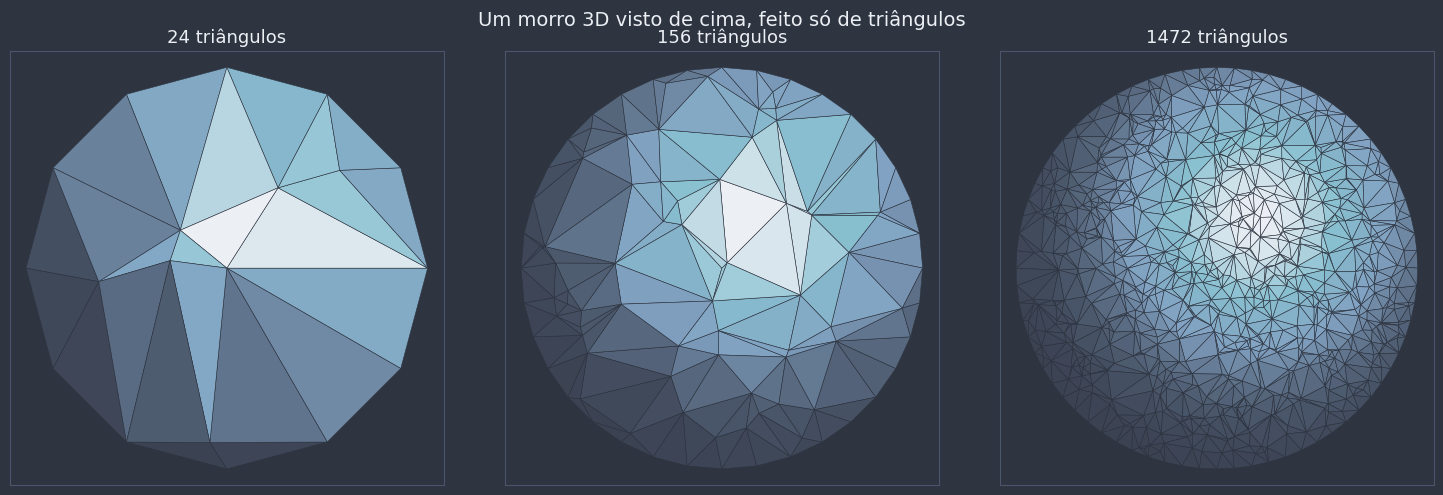

In [18]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.tri import Triangulation

mapa_nord = LinearSegmentedColormap.from_list("nord", [NORD_PAINEL, COR_SECUNDARIA, COR_PONTO, NORD_TEXTO])
rng = np.random.default_rng(3)

fig, eixos = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (aneis, internos) in zip(eixos, [(1, 6), (3, 60), (6, 700)]):
    # Pontos na borda de um disco (um "morro" visto de cima) + pontos espalhados por dentro
    angulos_borda = np.linspace(0, 2 * np.pi, 12 * aneis, endpoint=False)
    raio = np.sqrt(rng.uniform(0, 0.95, internos))
    teta = rng.uniform(0, 2 * np.pi, internos)
    x = np.concatenate([np.cos(angulos_borda), raio * np.cos(teta), [0]])
    y = np.concatenate([np.sin(angulos_borda), raio * np.sin(teta), [0]])
    malha = Triangulation(x, y)
    # "Luz" sobre o morro: cada triângulo recebe uma cor pela altura do seu centro
    centros_x, centros_y = x[malha.triangles].mean(axis=1), y[malha.triangles].mean(axis=1)
    altura = np.exp(-2.5 * ((centros_x - 0.2) ** 2 + (centros_y - 0.25) ** 2))
    preparar_eixo(ax, [(-1, -1), (1, 1)], margem=0.08)
    ax.tripcolor(malha, facecolors=altura, cmap=mapa_nord, edgecolors=NORD_FUNDO, linewidth=0.4)
    ax.set_title(f"{len(malha.triangles)} triângulos", color=NORD_TEXTO, fontsize=13)
fig.suptitle("Um morro 3D visto de cima, feito só de triângulos", color=NORD_TEXTO, fontsize=14)
plt.tight_layout()
plt.show()

📖 **Leitura complementar:** [Desigualdade triangular](https://pt.wikipedia.org/wiki/Desigualdade_triangular) · [Malha poligonal](https://pt.wikipedia.org/wiki/Malha_poligonal)

**Pergunta de checagem:** com varetas de 3 cm, 4 cm e 8 cm é possível formar um triângulo? E se trocarmos a de 8 cm por uma de 7 cm?

**Pergunta de checagem:** num triângulo, $\hat{A} = 80^\circ$ e $\hat{B} = 45^\circ$. Qual é o maior lado? E o menor?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Triângulo | reunião dos segmentos $\overline{AB}$, $\overline{BC}$, $\overline{CA}$, com A, B, C **não colineares**; notação $\triangle ABC$ |
| Elementos | vértices A, B, C; lados $a = BC$, $b = CA$, $c = AB$; ângulos internos $\hat{A}, \hat{B}, \hat{C}$; ângulos externos; perímetro $a + b + c$ |
| Convenção | o lado de letra **minúscula** é **oposto** ao vértice de mesma letra maiúscula |
| Ângulo externo | lado + prolongamento do outro lado; interno + externo = 180° (no mesmo vértice) |
| Quanto aos lados | **equilátero** (3 lados congruentes), **isósceles** (pelo menos 2), **escaleno** (3 diferentes); todo equilátero é isósceles |
| Quanto aos ângulos | **acutângulo** (3 agudos), **retângulo** (1 reto; **catetos** formam o reto, **hipotenusa** é oposta a ele), **obtusângulo** (1 obtuso) |
| Isósceles | ângulos da base congruentes; no equilátero, os três ângulos medem 60° |
| Soma dos internos | $\hat{A} + \hat{B} + \hat{C} = 180^\circ$ (no máximo um ângulo reto ou obtuso) |
| Retângulo | os dois ângulos agudos são complementares (somam 90°) |
| Teorema do ângulo externo | $\text{ext}(C) = \hat{A} + \hat{B}$ (a soma dos dois internos não adjacentes) |
| Desigualdade triangular | $\lvert b - c \rvert < a < b + c$ (e o mesmo para $b$ e $c$) |
| Teste rápido | soma dos dois menores **>** maior ⟹ forma triângulo; **=** ⟹ degenerado; **<** ⟹ não fecha |
| Lados × ângulos | ao maior lado opõe-se o maior ângulo (e vice-versa); lados congruentes ⟺ ângulos opostos congruentes |

**A ideia central:** três pontos não colineares bastam para formar a figura mais simples e mais **rígida** da geometria plana. Seus ângulos sempre somam 180°, seus lados obedecem à desigualdade triangular, e lados e ângulos andam juntos: o maior de um fica sempre de frente para o maior do outro.

## Exercícios

**Básico**
1. Classificar triângulos quanto aos lados (dadas as medidas dos lados) e quanto aos ângulos (dadas as medidas dos ângulos).
2. Calcular o terceiro ângulo interno de um triângulo e um ângulo externo.
3. Decidir, à mão e com uma função, se trios de medidas formam um triângulo.

**Intermediário**

4. Classificar triângulos dados pelas coordenadas dos vértices, montando uma função a partir das ferramentas das seções 1 e 2.
5. Encontrar os ângulos de triângulos isósceles a partir do ângulo do vértice ou de um ângulo da base.
6. Encontrar ângulos com a ajuda do teorema do ângulo externo, em figuras com lados prolongados.

**Desafio**

7. Descobrir, por força bruta, todos os valores inteiros possíveis para o terceiro lado de um triângulo com lados 5 e 9.
8. Encontrar a incógnita quando os três ângulos são dados por expressões e classificar o triângulo.

Gabarito completo com resolução comentada em [`0404b_triangulos_conceito_elementos_e_classificacao_gabarito.ipynb`](0404b_triangulos_conceito_elementos_e_classificacao_gabarito.ipynb) — tente resolver sozinho antes de olhar.

In [19]:
# Ferramenta usada pelas células de verificação: execute esta célula antes dos exercícios.
import unicodedata


def normalizar(texto) -> str:
    """Tira acentos, espaços extras e maiúsculas, para aceitar 'isosceles' tanto quanto 'Isósceles'."""
    sem_acento = unicodedata.normalize("NFD", str(texto)).encode("ascii", "ignore").decode()
    return sem_acento.strip().lower()

### Básico

In [ ]:
# Exercício Básico 1:
# (a) Classifique QUANTO AOS LADOS cada triângulo de `lados_ex1a` (cada item é (a, b, c)).
#     Use "equilátero", "isósceles" ou "escaleno"; para o equilátero, use "equilátero".
# (b) Classifique QUANTO AOS ÂNGULOS cada triângulo de `angulos_ex1b` (cada item são os
#     três ângulos internos, em graus). Use "acutângulo", "retângulo" ou "obtusângulo".
# Responda com listas de textos, na mesma ordem dos dados.
lados_ex1a = [(5, 5, 5), (3, 4, 5), (7, 7, 10), (6, 8, 6), (2.5, 2.5, 2.5), (4, 6, 9)]
angulos_ex1b = [(60, 60, 60), (90, 45, 45), (100, 40, 40), (30, 60, 90), (80, 70, 30), (20, 35, 125)]

classificacoes_ex1a = [..., ..., ..., ..., ..., ...]
classificacoes_ex1b = [..., ..., ..., ..., ..., ...]

print(classificacoes_ex1a)
print(classificacoes_ex1b)

In [ ]:
# Verificação
gabarito_ex1a = ["equilátero", "escaleno", "isósceles", "isósceles", "equilátero", "escaleno"]
gabarito_ex1b = ["acutângulo", "retângulo", "obtusângulo", "retângulo", "acutângulo", "obtusângulo"]
assert classificacoes_ex1a is not ... and len(classificacoes_ex1a) == len(lados_ex1a), (
    "Tente de novo, revise: a lista (a) precisa ter uma classificação para cada um dos "
    f"{len(lados_ex1a)} triângulos (seção 2 - Classificação dos triângulos)."
)
for lados, resposta, certa in zip(lados_ex1a, classificacoes_ex1a, gabarito_ex1a):
    assert resposta is not ... and normalizar(resposta) == normalizar(certa), (
        f"Tente de novo, revise: o triângulo de lados {lados} foi classificado errado; conte "
        "quantos lados são iguais (seção 2 - Classificação dos triângulos)."
    )
assert classificacoes_ex1b is not ... and len(classificacoes_ex1b) == len(angulos_ex1b), (
    "Tente de novo, revise: a lista (b) precisa ter uma classificação para cada um dos "
    f"{len(angulos_ex1b)} triângulos (seção 2 - Classificação dos triângulos)."
)
for angulos, resposta, certa in zip(angulos_ex1b, classificacoes_ex1b, gabarito_ex1b):
    assert resposta is not ... and normalizar(resposta) == normalizar(certa), (
        f"Tente de novo, revise: o triângulo de ângulos {angulos} foi classificado errado; olhe "
        "para o MAIOR ângulo e compare com 90° (seção 2 - Classificação dos triângulos)."
    )
print("Certo!")

In [ ]:
# Exercício Básico 2:
# (a) Dois ângulos internos de um triângulo medem 48° e 67°. Quanto mede o terceiro?
#     Guarde em `terceiro_ex2a`.
# (b) Quanto mede o ângulo externo adjacente a esse terceiro ângulo? Guarde em `externo_ex2b`.
# (c) Complete a função `terceiro_angulo_ex2`, que recebe dois ângulos internos e devolve
#     o terceiro.
terceiro_ex2a = ...
externo_ex2b = ...


def terceiro_angulo_ex2(alfa: float, beta: float) -> float:
    ...


print(terceiro_ex2a, externo_ex2b, terceiro_angulo_ex2(90, 35))

In [ ]:
# Verificação
assert terceiro_ex2a is not ... and math.isclose(terceiro_ex2a, 65), (
    "Tente de novo, revise: os três ângulos internos somam 180°, então o terceiro é "
    "180° − 48° − 67° (seção 3 - Soma dos ângulos internos e ângulo externo)."
)
assert externo_ex2b is not ... and math.isclose(externo_ex2b, 115), (
    "Tente de novo, revise: o externo é suplementar do interno adjacente; ou, pelo teorema, "
    "é a soma dos outros dois internos (seção 3 - Soma dos ângulos internos e ângulo externo)."
)
for alfa, beta in [(48, 67), (90, 35), (60, 60), (100, 20.5), (1, 1)]:
    resposta = terceiro_angulo_ex2(alfa, beta)
    assert resposta is not None and math.isclose(resposta, 180 - alfa - beta), (
        f"Tente de novo, revise: com {alfa}° e {beta}°, o terceiro ângulo é 180° menos a soma "
        "dos dois (seção 3 - Soma dos ângulos internos e ângulo externo)."
    )
print("Certo!")

In [ ]:
# Exercício Básico 3:
# (a) SEM usar o computador para testar, responda: cada trio de `trios_ex3` forma um
#     triângulo? Use True ou False, na mesma ordem.
# (b) Complete a função `forma_triangulo_ex3`, que recebe três medidas e devolve True se
#     elas formam um triângulo e False caso contrário. Lembre que medidas de lados
#     precisam ser positivas.
trios_ex3 = [(3, 4, 5), (1, 2, 3), (6, 6, 11), (2, 9, 5), (10, 10, 10), (4, 4, 8.5), (0.5, 0.7, 1)]

respostas_ex3a = [..., ..., ..., ..., ..., ..., ...]


def forma_triangulo_ex3(a: float, b: float, c: float) -> bool:
    ...


print(respostas_ex3a)
print([forma_triangulo_ex3(*trio) for trio in trios_ex3])

In [ ]:
# Verificação
gabarito_ex3 = [True, False, True, False, True, False, True]
assert respostas_ex3a is not ... and len(respostas_ex3a) == len(trios_ex3), (
    f"Tente de novo, revise: responda True ou False para cada um dos {len(trios_ex3)} trios "
    "(seção 4 - Desigualdades nos triângulos)."
)
for trio, resposta, certa in zip(trios_ex3, respostas_ex3a, gabarito_ex3):
    assert resposta is certa, (
        f"Tente de novo, revise: no trio {trio}, some os dois menores e compare com o maior; "
        "se a soma for igual, o triângulo é degenerado e NÃO conta (seção 4 - Desigualdades nos triângulos)."
    )
casos_ex3b = trios_ex3 + [(10, 2, 1), (1, 10, 2), (5, 5, 0), (-3, 4, 5), (7, 3, 5)]
for trio in casos_ex3b:
    certo = min(trio) > 0 and 2 * max(trio) < sum(trio)
    assert forma_triangulo_ex3(*trio) is certo, (
        f"Tente de novo, revise: para {trio} a função deveria devolver {certo}; teste as três "
        "desigualdades (ou o maior lado contra a soma dos outros) e rejeite medidas <= 0 "
        "(seção 4 - Desigualdades nos triângulos)."
    )
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 4: complete a função `classificar_ex4`, que recebe os vértices
# A, B e C por coordenadas e devolve a tupla
#     (classificação quanto aos lados, classificação quanto aos ângulos),
# com os mesmos nomes da seção 2.
# Use as ferramentas `distancia` e `medir_angulo` da seção 1 e compare medidas com
# math.isclose (nunca com ==). Não vale chamar `classificar_triangulo`, a ideia é montá-la
# de novo com as suas mãos!
# (Se aparecer NameError, rode antes as células das seções 1 e 2.)


def classificar_ex4(A, B, C) -> tuple[str, str]:
    ...


print(classificar_ex4((0, 0), (4, 0), (0, 3)))

In [ ]:
# Verificação
casos_ex4 = {
    ((0, 0), (2, 0), (1, math.sqrt(3))): ("equilátero", "acutângulo"),
    ((0, 0), (4, 0), (0, 3)): ("escaleno", "retângulo"),
    ((0, 0), (4, 0), (2, 0.9)): ("isósceles", "obtusângulo"),
    ((1, 1), (5, 1), (3, 3)): ("isósceles", "retângulo"),
    ((0, 0), (5, 0), (2, 3)): ("escaleno", "acutângulo"),
    ((0, 0), (6, 0), (-2, 1)): ("escaleno", "obtusângulo"),
    ((-1, 0), (1, 0), (0, 4)): ("isósceles", "acutângulo"),
}
for (A_, B_, C_), (certo_lados, certo_angulos) in casos_ex4.items():
    resposta = classificar_ex4(A_, B_, C_)
    assert resposta is not None and len(resposta) == 2, (
        "Tente de novo, revise: a função deve devolver uma tupla com DUAS classificações "
        "(seção 2 - Classificação dos triângulos)."
    )
    assert normalizar(resposta[0]) == normalizar(certo_lados), (
        f"Tente de novo, revise: o triângulo {A_}, {B_}, {C_} é {certo_lados}; meça os três lados "
        "com `distancia` e compare com math.isclose (seção 2 - Classificação dos triângulos)."
    )
    assert normalizar(resposta[1]) == normalizar(certo_angulos), (
        f"Tente de novo, revise: o triângulo {A_}, {B_}, {C_} é {certo_angulos}; meça os três "
        "ângulos com `medir_angulo` e olhe para o maior (seção 2 - Classificação dos triângulos)."
    )
print("Certo!")

In [ ]:
# Exercício Intermediário 5: triângulos isósceles.
# (a) O ângulo do vértice (oposto à base) de um triângulo isósceles mede 40°. Quanto mede
#     cada ângulo da base? Guarde em `angulo_base_ex5a`.
# (b) Num triângulo isósceles, cada ângulo da base mede 35°. Quanto mede o ângulo do
#     vértice? Guarde em `angulo_vertice_ex5b`.
# (c) Como o triângulo do item (b) se classifica quanto aos ângulos? Guarde o texto em
#     `classe_ex5c`.
# (d) Complete a função `angulo_base_ex5`, que recebe o ângulo do vértice e devolve a
#     medida de cada ângulo da base.
angulo_base_ex5a = ...
angulo_vertice_ex5b = ...
classe_ex5c = ...


def angulo_base_ex5(vertice: float) -> float:
    ...


print(angulo_base_ex5a, angulo_vertice_ex5b, classe_ex5c, angulo_base_ex5(100))

In [ ]:
# Verificação
assert angulo_base_ex5a is not ... and math.isclose(angulo_base_ex5a, 70), (
    "Tente de novo, revise: os dois ângulos da base são congruentes e, junto com o de 40°, "
    "somam 180° (seção 3 - Soma dos ângulos internos e ângulo externo)."
)
assert angulo_vertice_ex5b is not ... and math.isclose(angulo_vertice_ex5b, 110), (
    "Tente de novo, revise: são DOIS ângulos da base de 35°; o do vértice é o que falta "
    "para 180° (seção 3 - Soma dos ângulos internos e ângulo externo)."
)
assert classe_ex5c is not ... and normalizar(classe_ex5c) == "obtusangulo", (
    "Tente de novo, revise: compare o maior ângulo do item (b) com 90° "
    "(seção 2 - Classificação dos triângulos)."
)
for vertice in (40, 100, 60, 90, 1, 179):
    resposta = angulo_base_ex5(vertice)
    assert resposta is not None and math.isclose(resposta, (180 - vertice) / 2), (
        f"Tente de novo, revise: com ângulo do vértice {vertice}°, sobram 180° − {vertice}° para "
        "dividir IGUALMENTE entre os dois ângulos da base (seção 3 - Soma dos ângulos internos e ângulo externo)."
    )
print("Certo!")

Execute a célula abaixo para ver as figuras do Exercício Intermediário 6.

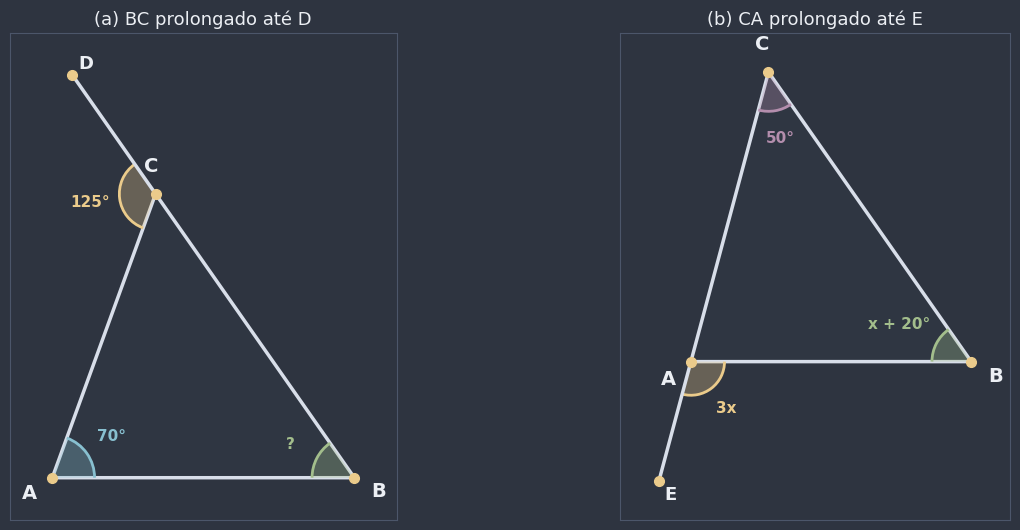

In [21]:
# Figuras do Exercício Intermediário 6 (apenas desenha; não precisa alterar)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.4))
fig.patch.set_facecolor(NORD_FUNDO)

# (a) Â = 70° e o lado BC prolongado além de C até D, com AĈD = 125°
A6, B6, C6 = construir_por_angulos(70, 55)
D6 = ponto_do_prolongamento(B6, C6, 2.4)
preparar_eixo(ax1, [A6, B6, C6, D6], margem=0.7)
desenhar_triangulo(ax1, A6, B6, C6, lados=False, angulos=False, cor_preenchimento=NORD_PAINEL)
ax1.plot(*zip(C6, D6), color=NORD_TEXTO_SEC, lw=2.5)
desenhar_ponto(ax1, D6, "D", deslocamento=(0.1, 0.1))
desenhar_arco(ax1, A6, B6, C6, raio=0.7, cor=CORES_VERTICES[0], rotulo="70°", raio_rotulo=1.2)
desenhar_arco(ax1, B6, C6, A6, raio=0.7, cor=CORES_VERTICES[1], rotulo="?", raio_rotulo=1.2)
desenhar_arco(ax1, C6, D6, A6, raio=0.6, cor=COR_AVISO, rotulo="125°", raio_rotulo=1.1)
ax1.set_title("(a) BC prolongado até D", color=NORD_TEXTO, fontsize=13)

# (b) externo em A = 3x (CA prolongado além de A até E), B̂ = x + 20°, Ĉ = 50°
A7, B7, C7 = construir_por_angulos(75, 55)
E7 = ponto_do_prolongamento(C7, A7, 2.2)
preparar_eixo(ax2, [A7, B7, C7, E7], margem=0.7)
desenhar_triangulo(ax2, A7, B7, C7, lados=False, angulos=False, cor_preenchimento=NORD_PAINEL)
ax2.plot(*zip(A7, E7), color=NORD_TEXTO_SEC, lw=2.5)
desenhar_ponto(ax2, E7, "E", deslocamento=(0.1, -0.35))
desenhar_arco(ax2, A7, E7, B7, raio=0.6, cor=COR_AVISO, rotulo="3x", raio_rotulo=1.05, marcar_reto=False)
desenhar_arco(ax2, B7, C7, A7, raio=0.7, cor=CORES_VERTICES[1], rotulo="x + 20°", raio_rotulo=1.45)
desenhar_arco(ax2, C7, A7, B7, raio=0.7, cor=CORES_VERTICES[2], rotulo="50°", raio_rotulo=1.2)
ax2.set_title("(b) CA prolongado até E", color=NORD_TEXTO, fontsize=13)

plt.tight_layout()
plt.show()

In [ ]:
# Exercício Intermediário 6: use as figuras acima.
# (a) Na figura (a), Â = 70° e o ângulo externo AĈD mede 125°.
#     - Quanto mede B̂? Guarde em `angulo_B_ex6a`.
#     - Quanto mede o ângulo interno Ĉ (= AĈB)? Guarde em `angulo_C_ex6a`.
#     - Como o △ABC se classifica quanto aos lados? Guarde o texto em `lados_ex6a`.
#       (Dica: seção 4, lados × ângulos.)
# (b) Na figura (b), o ângulo externo em A mede 3x, B̂ = x + 20° e Ĉ = 50°.
#     - Encontre x. Guarde em `x_ex6b`.
#     - Quanto mede o ângulo INTERNO Â? Guarde em `angulo_A_ex6b`.
angulo_B_ex6a = ...
angulo_C_ex6a = ...
lados_ex6a = ...

x_ex6b = ...
angulo_A_ex6b = ...

print(angulo_B_ex6a, angulo_C_ex6a, lados_ex6a, x_ex6b, angulo_A_ex6b)

In [ ]:
# Verificação
assert angulo_B_ex6a is not ... and math.isclose(angulo_B_ex6a, 55), (
    "Tente de novo, revise: o externo em C é a soma dos internos não adjacentes, então "
    "125° = 70° + B̂ (seção 3 - Soma dos ângulos internos e ângulo externo)."
)
assert angulo_C_ex6a is not ... and math.isclose(angulo_C_ex6a, 55), (
    "Tente de novo, revise: o interno e o externo de C são suplementares "
    "(seção 3 - Soma dos ângulos internos e ângulo externo)."
)
assert lados_ex6a is not ... and normalizar(lados_ex6a) == "isosceles", (
    "Tente de novo, revise: B̂ e Ĉ são congruentes, então os lados opostos a eles também são "
    "(seção 4 - Desigualdades nos triângulos)."
)
assert x_ex6b is not ... and math.isclose(x_ex6b, 35), (
    "Tente de novo, revise: pelo teorema do ângulo externo, 3x = (x + 20°) + 50° "
    "(seção 3 - Soma dos ângulos internos e ângulo externo)."
)
assert angulo_A_ex6b is not ... and math.isclose(angulo_A_ex6b, 75), (
    "Tente de novo, revise: o interno Â é o suplemento do externo 3x "
    "(seção 3 - Soma dos ângulos internos e ângulo externo)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 7: um triângulo tem dois lados medindo 5 e 9.
# (a) Quais valores INTEIROS o terceiro lado pode assumir? Descubra por força bruta: teste
#     todos os inteiros de 1 a 30 com a desigualdade triangular (pode usar a função
#     `forma_triangulo` da seção 4) e guarde os que funcionam, em ordem crescente, na
#     lista `valores_ex7`.
# (b) Quantos valores são? Guarde em `quantidade_ex7`.
# (c) Qual seria o intervalo de valores REAIS possíveis para o terceiro lado? Guarde as
#     duas pontas (que não fazem parte do intervalo) na tupla `intervalo_ex7 = (menor, maior)`.
valores_ex7 = ...
quantidade_ex7 = ...
intervalo_ex7 = (..., ...)

print(valores_ex7, quantidade_ex7, intervalo_ex7)

In [ ]:
# Verificação
assert valores_ex7 is not ... and list(valores_ex7) == list(range(5, 14)), (
    "Tente de novo, revise: o terceiro lado x precisa satisfazer |9 − 5| < x < 9 + 5; percorra "
    "os inteiros com um for e guarde os que passam no teste (seção 4 - Desigualdades nos triângulos)."
)
assert quantidade_ex7 is not ... and quantidade_ex7 == 9, (
    "Tente de novo, revise: conte quantos elementos tem a lista do item (a) "
    "(seção 4 - Desigualdades nos triângulos)."
)
assert intervalo_ex7 is not ... and tuple(intervalo_ex7) == (4, 14), (
    "Tente de novo, revise: as pontas do intervalo são a diferença e a soma dos dois lados "
    "conhecidos (seção 4 - Desigualdades nos triângulos)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 8:
# (a) Os ângulos internos de um triângulo medem x, 2x e 3x.
#     - Encontre x. Guarde em `x_ex8a`.
#     - Guarde os três ângulos, do menor para o maior, na tupla `angulos_ex8a`.
#     - Classifique o triângulo: tupla `classificacao_ex8a` = (quanto aos lados, quanto aos
#       ângulos). Dica para os lados: seção 4, lados × ângulos.
# (b) Agora os ângulos internos medem x, x e 4x. Faça o mesmo: `x_ex8b`, `angulos_ex8b` e
#     `classificacao_ex8b`.
x_ex8a = ...
angulos_ex8a = (..., ..., ...)
classificacao_ex8a = (..., ...)

x_ex8b = ...
angulos_ex8b = (..., ..., ...)
classificacao_ex8b = (..., ...)

print(x_ex8a, angulos_ex8a, classificacao_ex8a)
print(x_ex8b, angulos_ex8b, classificacao_ex8b)

In [ ]:
# Verificação
assert x_ex8a is not ... and math.isclose(x_ex8a, 30), (
    "Tente de novo, revise: x + 2x + 3x = 180°, então 6x = 180° "
    "(seção 3 - Soma dos ângulos internos e ângulo externo)."
)
assert angulos_ex8a is not ... and all(
    a is not ... and math.isclose(a, c) for a, c in zip(angulos_ex8a, (30, 60, 90))
), (
    "Tente de novo, revise: substitua o valor de x em x, 2x e 3x "
    "(seção 3 - Soma dos ângulos internos e ângulo externo)."
)
assert tuple(normalizar(t) for t in classificacao_ex8a) == ("escaleno", "retangulo"), (
    "Tente de novo, revise: três ângulos diferentes se opõem a três lados diferentes, e um "
    "deles é de 90° (seção 4 - Desigualdades nos triângulos)."
)
assert x_ex8b is not ... and math.isclose(x_ex8b, 30), (
    "Tente de novo, revise: x + x + 4x = 180°, então 6x = 180° "
    "(seção 3 - Soma dos ângulos internos e ângulo externo)."
)
assert angulos_ex8b is not ... and all(
    a is not ... and math.isclose(a, c) for a, c in zip(angulos_ex8b, (30, 30, 120))
), (
    "Tente de novo, revise: substitua o valor de x em x, x e 4x "
    "(seção 3 - Soma dos ângulos internos e ângulo externo)."
)
assert tuple(normalizar(t) for t in classificacao_ex8b) == ("isosceles", "obtusangulo"), (
    "Tente de novo, revise: dois ângulos congruentes se opõem a dois lados congruentes, e o "
    "maior ângulo passa de 90° (seção 4 - Desigualdades nos triângulos)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb) (pontos colineares e não colineares; três pontos não colineares determinam um plano)
- [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (os lados são segmentos; medida, congruência e a fórmula da distância; o caminho reto é o mais curto)
- [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (medida e classificação de ângulos; suplementares e complementares; opostos pelo vértice)

**Isso será usado em:**
- [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (os critérios de congruência, que explicam a rigidez do gancho, e a prova das propriedades do isósceles)
- [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) (a demonstração formal da soma de 180° dos ângulos internos)
- 📌 Pontos Notáveis do Triângulo (baricentro, incentro, circuncentro e ortocentro)
- 📌 Triângulos Retângulos (Teorema de Pitágoras e a classificação pelos ângulos usando só os lados)
- 📌 Triângulos Quaisquer (relações métricas em triângulos que não são retângulos)